# 04 Empirical Analysis

This notebook applies the validated GC and TE framework to the four empirical source--FX channels.

The empirical specification is fixed before examining the results. All volatility inputs are taken directly from the processed dataset produced in Notebook 01.

In [13]:

from pathlib import Path

import numpy as np
import pandas as pd

# Statistics / econometrics
from scipy import stats
import statsmodels.api as sm
from statsmodels.tsa.stattools import grangercausalitytests

# Model comparison / regression utilities
from statsmodels.regression.linear_model import OLS

# Reproducibility
SEED = 42
rng = np.random.default_rng(SEED)

# Display
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

## 1. Load final processed data

The empirical analysis uses the final processed panel from Notebook 01.

No volatility variables are reconstructed here.

In [3]:
PROJECT_DIR = Path("..")
DATA_DIR = PROJECT_DIR / "data"
PROCESSED_DIR = DATA_DIR / "processed"

DATA_FILE = PROCESSED_DIR / "master_panel_wide.csv"

df = pd.read_csv(DATA_FILE)

# Remove accidental CSV index column if present
df = df.loc[:, ~df.columns.str.startswith("Unnamed")]

# Parse date
df["Date"] = pd.to_datetime(df["Date"])

# Sort and use Date as index
df = (
    df.sort_values("Date")
      .set_index("Date")
)

print(f"Loaded: {DATA_FILE}")
print(f"Shape: {df.shape}")
print(f"Date range: {df.index.min().date()} to {df.index.max().date()}")

Loaded: ../data/processed/master_panel_wide.csv
Shape: (2595, 115)
Date range: 2015-01-02 to 2024-12-31


In [4]:
REQUIRED_COLUMNS = [
    # FX targets
    "EURUSD_dlogvol",
    "USDJPY_dlogvol",
    "AUDUSD_dlogvol",
    "USDCAD_dlogvol",

    # Source markets
    "US_DE_2Y_Diff_dlogvol",
    "US_JP_2Y_Diff_dlogvol",
    "Gold_dlogvol",
    "Brent_dlogvol",

    # Common-factor control
    "DXY_dlogvol",
]

missing_cols = [col for col in REQUIRED_COLUMNS if col not in df.columns]

if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

print("All required empirical variables are available.")
print(df[REQUIRED_COLUMNS].notna().sum())

All required empirical variables are available.
EURUSD_dlogvol           2593
USDJPY_dlogvol           2593
AUDUSD_dlogvol           2593
USDCAD_dlogvol           2593
US_DE_2Y_Diff_dlogvol    2168
US_JP_2Y_Diff_dlogvol    2009
Gold_dlogvol             2581
Brent_dlogvol            2567
DXY_dlogvol              2587
dtype: int64


## 2. Fixed empirical specification
The empirical specification below is fixed before examining the Chapter 6 results.

The same settings validated in Chapters 4 and 5 are used throughout the empirical analysis. Parameters are not re-selected according to empirical significance.

- GC: maximum lag of 5 trading days, with lag order selected by AIC.
- TE: target history \(m=1\), \(k=10\) nearest neighbours, source delays 1--5, and 100 circular-shift surrogates.
- Conditional TE: DXY history \(m_Z=2\).
- Statistical significance: 5%.

In [15]:
# ============================================================
# Fixed empirical specification
# ============================================================

ALPHA = 0.05

# ------------------------------------------------------------
# Empirical channels
# ------------------------------------------------------------

CHANNELS = {
    "US-DE 2Y -> EURUSD": {
        "source": "US_DE_2Y_Diff_dlogvol",
        "fx": "EURUSD_dlogvol",
        "type": "Rates-FX",
    },

    "US-JP 2Y -> USDJPY": {
        "source": "US_JP_2Y_Diff_dlogvol",
        "fx": "USDJPY_dlogvol",
        "type": "Rates-FX",
    },

    "Gold -> AUDUSD": {
        "source": "Gold_dlogvol",
        "fx": "AUDUSD_dlogvol",
        "type": "Commodity-FX",
    },

    "Brent -> USDCAD": {
        "source": "Brent_dlogvol",
        "fx": "USDCAD_dlogvol",
        "type": "Commodity-FX",
    },
}

# Both directions are always estimated
DIRECTIONS = ["X->Y", "Y->X"]

# ------------------------------------------------------------
# Common-factor control
# ------------------------------------------------------------

DXY_CONTROL = "DXY_dlogvol"

# ------------------------------------------------------------
# Granger causality
# ------------------------------------------------------------

GC_MAX_LAG = 5
GC_LAG_SELECTION = "AIC"

# ------------------------------------------------------------
# Transfer Entropy
# ------------------------------------------------------------

TE_M = 1
TE_K = 10
TE_LAGS = [1, 2, 3, 4, 5]
TE_SURROGATES = 100

# Conditional TE
TE_MZ = 2

# ------------------------------------------------------------
# FOMC event window
# ------------------------------------------------------------

FOMC_WINDOW = [-1, 0, 1]

## 3. Empirical channels

Four economically motivated source--FX channels are analysed.

For each channel:

- \(X_t\) is the source-market volatility shock.
- \(Y_t\) is the FX volatility shock.
- \(Z_t\) is the DXY volatility shock used in the conditional analysis.

Both \(X \rightarrow Y\) and \(Y \rightarrow X\) are tested.

In [6]:
CHANNELS = {
    "US-DE 2Y -> EURUSD": {
        "source": "US_DE_2Y_Diff_dlogvol",
        "fx": "EURUSD_dlogvol",
        "type": "Rates-FX",
    },

    "US-JP 2Y -> USDJPY": {
        "source": "US_JP_2Y_Diff_dlogvol",
        "fx": "USDJPY_dlogvol",
        "type": "Rates-FX",
    },

    "Gold -> AUDUSD": {
        "source": "Gold_dlogvol",
        "fx": "AUDUSD_dlogvol",
        "type": "Commodity-FX",
    },

    "Brent -> USDCAD": {
        "source": "Brent_dlogvol",
        "fx": "USDCAD_dlogvol",
        "type": "Commodity-FX",
    },
}

DXY_CONTROL = "DXY_dlogvol"

In [7]:
channel_table = pd.DataFrame([
    {
        "Channel": name,
        "Type": spec["type"],
        "Source X": spec["source"],
        "FX Y": spec["fx"],
        "Control Z": DXY_CONTROL,
    }
    for name, spec in CHANNELS.items()
])

channel_table

,Channel,Type,Source X,FX Y,Control Z
0,US-DE 2Y -> EURUSD,Rates-FX,US_DE_2Y_Diff_dlogvol,EURUSD_dlogvol,DXY_dlogvol
1,US-JP 2Y -> USDJPY,Rates-FX,US_JP_2Y_Diff_dlogvol,USDJPY_dlogvol,DXY_dlogvol
2,Gold -> AUDUSD,Commodity-FX,Gold_dlogvol,AUDUSD_dlogvol,DXY_dlogvol
3,Brent -> USDCAD,Commodity-FX,Brent_dlogvol,USDCAD_dlogvol,DXY_dlogvol


## 4. Channel-specific alignment

Each channel is aligned only on the variables required for that specification.

The bivariate sample uses \(X_t\) and \(Y_t\).  
The conditional sample additionally requires the DXY volatility shock \(Z_t\).

A single balanced sample across all markets is not imposed.

In [8]:
def get_channel_data(df, source_col, fx_col, control_col=None):
    """
    Align one empirical channel on the variables required by the specification.
    """

    cols = [source_col, fx_col]

    if control_col is not None:
        cols.append(control_col)

    out = df[cols].copy()
    out = out.replace([np.inf, -np.inf], np.nan)
    out = out.dropna()

    rename_map = {
        source_col: "X",
        fx_col: "Y",
    }

    if control_col is not None:
        rename_map[control_col] = "Z"

    out = out.rename(columns=rename_map)

    return out

In [9]:
channel_data = {}

for channel_name, spec in CHANNELS.items():

    source_col = spec["source"]
    fx_col = spec["fx"]

    bivariate = get_channel_data(
        df=df,
        source_col=source_col,
        fx_col=fx_col,
    )

    conditional = get_channel_data(
        df=df,
        source_col=source_col,
        fx_col=fx_col,
        control_col=DXY_CONTROL,
    )

    channel_data[channel_name] = {
        "bivariate": bivariate,
        "conditional": conditional,
    }

print("Channel-specific samples created.")

Channel-specific samples created.


In [10]:
alignment_rows = []

for channel_name, samples in channel_data.items():

    biv = samples["bivariate"]
    cond = samples["conditional"]

    alignment_rows.append({
        "Channel": channel_name,

        "Bivariate N": len(biv),
        "Bivariate Start": biv.index.min().date(),
        "Bivariate End": biv.index.max().date(),

        "Conditional N": len(cond),
        "Conditional Start": cond.index.min().date(),
        "Conditional End": cond.index.max().date(),

        "N lost with DXY": len(biv) - len(cond),
    })

alignment_summary = pd.DataFrame(alignment_rows)

alignment_summary

,Channel,Bivariate N,Bivariate Start,Bivariate End,Conditional N,Conditional Start,Conditional End,N lost with DXY
0,US-DE 2Y -> EURUSD,2168,2015-01-06,2024-12-31,2168,2015-01-06,2024-12-31,0
1,US-JP 2Y -> USDJPY,2009,2015-01-06,2024-12-31,2009,2015-01-06,2024-12-31,0
2,Gold -> AUDUSD,2581,2015-01-06,2024-12-31,2579,2015-01-06,2024-12-31,2
3,Brent -> USDCAD,2567,2015-01-06,2024-12-31,2563,2015-01-06,2024-12-31,4


In [11]:
for channel_name, samples in channel_data.items():

    print("=" * 70)
    print(channel_name)

    for sample_name, data in samples.items():

        print(
            f"{sample_name:12s} | "
            f"N={len(data):4d} | "
            f"{data.index.min().date()} to {data.index.max().date()} | "
            f"duplicates={data.index.duplicated().sum()} | "
            f"missing={data.isna().sum().sum()} | "
            f"inf={np.isinf(data.to_numpy()).sum()}"
        )


US-DE 2Y -> EURUSD
bivariate    | N=2168 | 2015-01-06 to 2024-12-31 | duplicates=0 | missing=0 | inf=0
conditional  | N=2168 | 2015-01-06 to 2024-12-31 | duplicates=0 | missing=0 | inf=0
US-JP 2Y -> USDJPY
bivariate    | N=2009 | 2015-01-06 to 2024-12-31 | duplicates=0 | missing=0 | inf=0
conditional  | N=2009 | 2015-01-06 to 2024-12-31 | duplicates=0 | missing=0 | inf=0
Gold -> AUDUSD
bivariate    | N=2581 | 2015-01-06 to 2024-12-31 | duplicates=0 | missing=0 | inf=0
conditional  | N=2579 | 2015-01-06 to 2024-12-31 | duplicates=0 | missing=0 | inf=0
Brent -> USDCAD
bivariate    | N=2567 | 2015-01-06 to 2024-12-31 | duplicates=0 | missing=0 | inf=0
conditional  | N=2563 | 2015-01-06 to 2024-12-31 | duplicates=0 | missing=0 | inf=0


In [12]:
variation_rows = []

for channel_name, samples in channel_data.items():

    data = samples["conditional"]

    variation_rows.append({
        "Channel": channel_name,
        "Std X": data["X"].std(),
        "Std Y": data["Y"].std(),
        "Std Z": data["Z"].std(),
    })

variation_summary = pd.DataFrame(variation_rows)

variation_summary

,Channel,Std X,Std Y,Std Z
0,US-DE 2Y -> EURUSD,0.054567,0.028207,0.028655
1,US-JP 2Y -> USDJPY,0.063777,0.062982,0.028751
2,Gold -> AUDUSD,0.030712,0.023272,0.027936
3,Brent -> USDCAD,0.070864,0.025056,0.027995


## 5. Full-Sample Linear Granger Causality

Linear Granger causality is estimated for each channel in both directions.

For each direction, lag order \(p=1,\ldots,5\) is selected by AIC. The final GC decision is based on a joint F-test of whether all lagged source coefficients are zero.

The individual source lag with the smallest coefficient p-value is also recorded for descriptive lag reporting, but it does not determine overall significance.

In [16]:
# ============================================================
# GC helper: build target-equation design matrix
# ============================================================

def _build_gc_design(x, y, order):
    """
    Build the target equation:

        Y_t ~ Y_{t-1,...,t-p} + X_{t-1,...,t-p} + constant

    Parameters
    ----------
    x : array-like
        Source series.
    y : array-like
        Target series.
    order : int
        Lag order p.

    Returns
    -------
    design : np.ndarray
        Regression design matrix.
    y_target : np.ndarray
        Aligned target observations.
    """

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    n = len(y)
    y_target = y[order:]

    cols = []

    # Target lags
    for lag in range(1, order + 1):
        cols.append(y[order - lag:n - lag])

    # Source lags
    for lag in range(1, order + 1):
        cols.append(x[order - lag:n - lag])

    design = np.column_stack(cols)
    design = sm.add_constant(design, has_constant="add")

    return design, y_target

In [17]:
# ============================================================
# GC helper: fit one target equation
# ============================================================

def _fit_gc_equation(x, y, order):
    """
    Fit:

        Y_t ~ Y lags + X lags

    Returns the fitted OLS model and the column positions
    corresponding to the source lags.
    """

    design, y_target = _build_gc_design(x, y, order)

    model = sm.OLS(y_target, design).fit()

    # Column layout:
    # [const, Y_lag1,...,Y_lag_p, X_lag1,...,X_lag_p]
    x_start = 1 + order
    x_lag_cols = list(range(x_start, x_start + order))

    return {
        "model": model,
        "x_lag_cols": x_lag_cols,
        "order": order,
    }

In [18]:
# ============================================================
# GC helper: select lag order by AIC
# ============================================================

def select_gc_lag_aic(x, y, max_lag=GC_MAX_LAG):
    """
    Select lag order p = 1,...,max_lag using the AIC
    of the target equation.
    """

    rows = []

    for order in range(1, max_lag + 1):

        fit = _fit_gc_equation(x, y, order)
        model = fit["model"]

        rows.append({
            "order": order,
            "aic": model.aic,
        })

    aic_table = pd.DataFrame(rows)

    best_order = int(
        aic_table.loc[aic_table["aic"].idxmin(), "order"]
    )

    return best_order, aic_table

In [19]:
# ============================================================
# Run one full-sample bivariate GC direction
# ============================================================

def run_gc_direction(
    x,
    y,
    direction,
    max_lag=GC_MAX_LAG,
    alpha=ALPHA,
):
    """
    Run bivariate linear GC for one direction.

    1. Select p by AIC over 1,...,max_lag.
    2. Fit the selected target equation.
    3. Jointly test whether all source-lag coefficients are zero.
    4. Record the individual source lag with the smallest p-value.
    """

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if len(x) != len(y):
        raise ValueError("Source and target must have equal length.")

    # --------------------------------------------------------
    # 1. Select lag order by AIC
    # --------------------------------------------------------

    selected_order, aic_table = select_gc_lag_aic(
        x=x,
        y=y,
        max_lag=max_lag,
    )

    # --------------------------------------------------------
    # 2. Fit selected target equation
    # --------------------------------------------------------

    fit = _fit_gc_equation(
        x=x,
        y=y,
        order=selected_order,
    )

    model = fit["model"]
    x_lag_cols = fit["x_lag_cols"]

    # --------------------------------------------------------
    # 3. Joint F-test:
    #    H0: beta_1 = ... = beta_p = 0
    # --------------------------------------------------------

    restriction = np.zeros(
        (selected_order, len(model.params))
    )

    for row, col in enumerate(x_lag_cols):
        restriction[row, col] = 1.0

    f_test = model.f_test(restriction)

    f_stat = float(np.asarray(f_test.fvalue).squeeze())
    global_pvalue = float(np.asarray(f_test.pvalue).squeeze())

    # --------------------------------------------------------
    # 4. Individual source-lag p-values
    # --------------------------------------------------------

    source_lag_pvalues = {
        lag: float(model.pvalues[col])
        for lag, col in zip(
            range(1, selected_order + 1),
            x_lag_cols
        )
    }

    best_lag = min(
        source_lag_pvalues,
        key=source_lag_pvalues.get
    )

    best_lag_pvalue = source_lag_pvalues[best_lag]

    return {
        "direction": direction,
        "selected_p": selected_order,
        "F_stat": f_stat,
        "global_pvalue": global_pvalue,
        "significant": global_pvalue < alpha,
        "best_source_lag": best_lag,
        "best_lag_pvalue": best_lag_pvalue,
        "source_lag_pvalues": source_lag_pvalues,
        "aic_table": aic_table,
    }

### Direction convention

For each channel, \(X\) is the economically motivated source market and \(Y\) is the FX market.

- `X -> Y`: source-market volatility shock predicts the FX volatility shock.
- `Y -> X`: FX volatility shock predicts the source-market volatility shock.

Lag order is selected independently for the two directions.

In [21]:
# ============================================================
# Full-sample bivariate GC: all channels, both directions
# ============================================================

gc_results = []
gc_details = {}

for channel_name, samples in channel_data.items():

    data = samples["bivariate"]

    x = data["X"].to_numpy()
    y = data["Y"].to_numpy()

    # --------------------------------------------------------
    # X -> Y
    # --------------------------------------------------------

    result_xy = run_gc_direction(
        x=x,
        y=y,
        direction="X->Y",
    )

    # --------------------------------------------------------
    # Y -> X
    # Exchange source and target
    # --------------------------------------------------------

    result_yx = run_gc_direction(
        x=y,
        y=x,
        direction="Y->X",
    )

    gc_details[channel_name] = {
        "X->Y": result_xy,
        "Y->X": result_yx,
    }

    for result in [result_xy, result_yx]:

        gc_results.append({
            "Channel": channel_name,
            "Direction": result["direction"],
            "N": len(data),
            "Selected p": result["selected_p"],
            "F statistic": result["F_stat"],
            "Global p-value": result["global_pvalue"],
            "Significant": result["significant"],
            "Best source lag": result["best_source_lag"],
            "Best lag p-value": result["best_lag_pvalue"],
        })

gc_results_df = pd.DataFrame(gc_results)

In [22]:
# ============================================================
# Full-sample GC summary
# ============================================================

gc_results_df

,Channel,Direction,N,Selected p,F statistic,Global p-value,Significant,Best source lag,Best lag p-value
0,US-DE 2Y -> EURUSD,X->Y,2168,1,2.9335,0.0869,False,1,0.0869
1,US-DE 2Y -> EURUSD,Y->X,2168,1,0.8448,0.3581,False,1,0.3581
2,US-JP 2Y -> USDJPY,X->Y,2009,1,0.0180,0.8932,False,1,0.8932
3,US-JP 2Y -> USDJPY,Y->X,2009,2,0.8939,0.4092,False,1,0.2664
4,Gold -> AUDUSD,X->Y,2581,1,0.0096,0.9221,False,1,0.9221
5,Gold -> AUDUSD,Y->X,2581,1,3.6891,0.0549,False,1,0.0549
6,Brent -> USDCAD,X->Y,2567,1,0.7463,0.3877,False,1,0.3877
7,Brent -> USDCAD,Y->X,2567,1,0.0034,0.9532,False,1,0.9532


In [23]:
# ============================================================
# AIC selection audit
# ============================================================

for channel_name, directions in gc_details.items():

    print("=" * 70)
    print(channel_name)

    for direction, result in directions.items():

        print(f"\n{direction}")
        display(result["aic_table"])

US-DE 2Y -> EURUSD

X->Y


,order,aic
0,1,-9311.9394
1,2,-9308.5613
2,3,-9299.6358
3,4,-9290.6510
4,5,-9288.1264



Y->X


,order,aic
0,1,-6450.0928
1,2,-6448.3139
2,3,-6443.1758
3,4,-6436.1979
4,5,-6428.7993


US-JP 2Y -> USDJPY

X->Y


...

,order,aic
0,1,-10651.5652
1,2,-10644.8703
2,3,-10635.9628
3,4,-10633.5768
4,5,-10634.3844


Brent -> USDCAD

X->Y


,order,aic
0,1,-11636.2959
1,2,-11627.0940
2,3,-11618.1543
3,4,-11609.0299
4,5,-11610.6654



Y->X


,order,aic
0,1,-6298.2188
1,2,-6291.7034
2,3,-6285.7313
3,4,-6282.6284
4,5,-6280.0248


In [24]:
# ============================================================
# Individual source-lag p-values
# ============================================================

lag_rows = []

for channel_name, directions in gc_details.items():

    for direction, result in directions.items():

        for lag, pvalue in result["source_lag_pvalues"].items():

            lag_rows.append({
                "Channel": channel_name,
                "Direction": direction,
                "Lag": lag,
                "Coefficient p-value": pvalue,
                "Selected p": result["selected_p"],
            })

gc_lag_pvalues_df = pd.DataFrame(lag_rows)

gc_lag_pvalues_df

,Channel,Direction,Lag,Coefficient p-value,Selected p
0,US-DE 2Y -> EURUSD,X->Y,1,0.0869,1
1,US-DE 2Y -> EURUSD,Y->X,1,0.3581,1
2,US-JP 2Y -> USDJPY,X->Y,1,0.8932,1
3,US-JP 2Y -> USDJPY,Y->X,1,0.2664,2
4,US-JP 2Y -> USDJPY,Y->X,2,0.4563,2
5,Gold -> AUDUSD,X->Y,1,0.9221,1
6,Gold -> AUDUSD,Y->X,1,0.0549,1
7,Brent -> USDCAD,X->Y,1,0.3877,1
8,Brent -> USDCAD,Y->X,1,0.9532,1


## 6. Full-Sample Transfer Entropy

Transfer Entropy is estimated for each channel in both directions using the specification validated in Chapter 5.

The baseline settings are:

- target-history embedding \(m=1\);
- \(k=10\) nearest neighbours;
- source delays \(\ell=1,\ldots,5\);
- \(B=100\) circular-shift surrogates.

Significance is based on the maximum TE statistic across all five candidate lags.

In [27]:
# ============================================================
# TE-specific imports
# ============================================================

from scipy.spatial import cKDTree
from scipy.special import digamma

# ============================================================
# TE helper: construct aligned vectors
# ============================================================

def build_te_vectors(x, y, source_lag, embedding=TE_M):
    """
    Construct:

        Y_t
        Y_{t-1},...,Y_{t-m}
        X_{t-source_lag}

    for one candidate source lag.
    """

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    start = max(source_lag, embedding)

    y_t = y[start:]

    x_source = x[
        start - source_lag:
        len(x) - source_lag
    ]

    y_history = np.column_stack([
        y[start - lag:len(y) - lag]
        for lag in range(1, embedding + 1)
    ])

    return y_t, y_history, x_source

In [28]:
# ============================================================
# KSG / Frenzel-Pompe conditional mutual information
# ============================================================

def ksg_cmi(y_t, y_history, x_source, k=TE_K):
    """
    Estimate:

        I(Y_t ; X_source | Y_history)

    using a nearest-neighbour conditional mutual-information estimator.
    """

    y_t = np.asarray(y_t, dtype=float).reshape(-1, 1)
    x_source = np.asarray(x_source, dtype=float).reshape(-1, 1)
    y_history = np.asarray(y_history, dtype=float)

    # Joint space: (Y_t, Y_history, X_source)
    joint = np.column_stack([
        y_t,
        y_history,
        x_source
    ])

    tree_joint = cKDTree(joint)

    dists, _ = tree_joint.query(
        joint,
        k=k + 1,
        p=np.inf
    )

    # Strictly smaller than the k-th neighbour distance
    eps = np.nextafter(dists[:, -1], 0)

    # Marginal spaces
    yz = np.column_stack([
        y_t,
        y_history
    ])

    xz = np.column_stack([
        x_source,
        y_history
    ])

    z = y_history

    tree_yz = cKDTree(yz)
    tree_xz = cKDTree(xz)
    tree_z = cKDTree(z)

    n_yz = (
        tree_yz.query_ball_point(
            yz,
            r=eps,
            p=np.inf,
            return_length=True
        ) - 1
    )

    n_xz = (
        tree_xz.query_ball_point(
            xz,
            r=eps,
            p=np.inf,
            return_length=True
        ) - 1
    )

    n_z = (
        tree_z.query_ball_point(
            z,
            r=eps,
            p=np.inf,
            return_length=True
        ) - 1
    )

    cmi = (
        digamma(k)
        - np.mean(
            digamma(n_xz + 1)
            + digamma(n_yz + 1)
            - digamma(n_z + 1)
        )
    )

    return float(cmi)

In [29]:
# ============================================================
# TE helper: estimate TE at one source lag
# ============================================================

def te_at_lag(
    x,
    y,
    lag,
    k=TE_K,
    embedding=TE_M,
):
    """
    Estimate TE from X to Y at one source lag.
    """

    y_t, y_history, x_source = build_te_vectors(
        x=x,
        y=y,
        source_lag=lag,
        embedding=embedding,
    )

    return ksg_cmi(
        y_t=y_t,
        y_history=y_history,
        x_source=x_source,
        k=k,
    )

In [30]:
# ============================================================
# Run one full-sample bivariate TE direction
# ============================================================

def run_te_direction(
    x,
    y,
    direction,
    lags=TE_LAGS,
    k=TE_K,
    embedding=TE_M,
    n_surrogates=TE_SURROGATES,
    alpha=ALPHA,
    seed=12345,
):
    """
    Run bivariate TE for one direction.

    1. Estimate TE at every candidate source lag.
    2. Record the maximum observed TE and its peak lag.
    3. Generate circular-shift source surrogates.
    4. For each surrogate, retain the maximum TE across all lags.
    5. Compute one global maximum-statistic p-value.
    """

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if len(x) != len(y):
        raise ValueError(
            "Source and target must have equal length."
        )

    rng = np.random.default_rng(seed)

    # --------------------------------------------------------
    # 1. Observed TE at each candidate lag
    # --------------------------------------------------------

    te_by_lag = {
        lag: te_at_lag(
            x=x,
            y=y,
            lag=lag,
            k=k,
            embedding=embedding,
        )
        for lag in lags
    }

    peak_lag = max(
        te_by_lag,
        key=te_by_lag.get
    )

    observed_max = te_by_lag[peak_lag]

    # --------------------------------------------------------
    # 2. Circular-shift surrogate maximum distribution
    # --------------------------------------------------------

    n = len(x)

    surrogate_maxima = np.empty(
        n_surrogates
    )

    for b in range(n_surrogates):

        shift = int(
            rng.integers(1, n)
        )

        x_shifted = np.roll(
            x,
            shift
        )

        surrogate_maxima[b] = max(
            te_at_lag(
                x=x_shifted,
                y=y,
                lag=lag,
                k=k,
                embedding=embedding,
            )
            for lag in lags
        )

    # --------------------------------------------------------
    # 3. Global maximum-statistic p-value
    # --------------------------------------------------------

    global_pvalue = (
        1
        + np.sum(
            surrogate_maxima >= observed_max
        )
    ) / (
        n_surrogates + 1
    )

    return {
        "direction": direction,

        "TE_by_lag": te_by_lag,

        "max_TE": float(observed_max),

        "peak_lag": int(peak_lag),

        "global_pvalue": float(
            global_pvalue
        ),

        "significant": bool(
            global_pvalue < alpha
        ),

        "surrogate_maxima": surrogate_maxima,
    }

### Direction and inference

For each channel:

- `X -> Y` tests source-market volatility shocks predicting FX volatility shocks.
- `Y -> X` tests the reverse direction.

The peak lag is the lag with the largest estimated TE within the five-day search window.

Overall significance is determined only by the global maximum-statistic surrogate p-value.

In [31]:
# ============================================================
# Full-sample bivariate TE: all channels, both directions
# ============================================================

te_results = []
te_details = {}

seed_counter = 10000

for channel_name, samples in channel_data.items():

    data = samples["bivariate"]

    x = data["X"].to_numpy()
    y = data["Y"].to_numpy()

    print("=" * 70)
    print(channel_name)

    # --------------------------------------------------------
    # X -> Y
    # --------------------------------------------------------

    print("Running X -> Y ...")

    result_xy = run_te_direction(
        x=x,
        y=y,
        direction="X->Y",
        seed=seed_counter,
    )

    seed_counter += 1

    # --------------------------------------------------------
    # Y -> X
    # --------------------------------------------------------

    print("Running Y -> X ...")

    result_yx = run_te_direction(
        x=y,
        y=x,
        direction="Y->X",
        seed=seed_counter,
    )

    seed_counter += 1

    te_details[channel_name] = {
        "X->Y": result_xy,
        "Y->X": result_yx,
    }

    for result in [
        result_xy,
        result_yx
    ]:

        te_results.append({
            "Channel": channel_name,
            "Direction": result["direction"],
            "N": len(data),
            "Max TE": result["max_TE"],
            "Peak lag": result["peak_lag"],
            "Global p-value": result["global_pvalue"],
            "Significant": result["significant"],
        })

    print("Done.\n")

US-DE 2Y -> EURUSD
Running X -> Y ...
Running Y -> X ...
Done.

US-JP 2Y -> USDJPY
Running X -> Y ...
Running Y -> X ...
Done.

Gold -> AUDUSD
Running X -> Y ...
Running Y -> X ...
Done.

Brent -> USDCAD
Running X -> Y ...
Running Y -> X ...
Done.



In [32]:
# ============================================================
# Full-sample TE summary
# ============================================================

te_results_df = pd.DataFrame(
    te_results
)

te_results_df

,Channel,Direction,N,Max TE,Peak lag,Global p-value,Significant
0,US-DE 2Y -> EURUSD,X->Y,2168,0.0165,4,0.0693,False
1,US-DE 2Y -> EURUSD,Y->X,2168,0.0137,3,0.1287,False
2,US-JP 2Y -> USDJPY,X->Y,2009,0.0179,1,0.0396,True
3,US-JP 2Y -> USDJPY,Y->X,2009,0.0135,4,0.2475,False
4,Gold -> AUDUSD,X->Y,2581,0.0136,3,0.1881,False
5,Gold -> AUDUSD,Y->X,2581,0.0045,4,0.7624,False
6,Brent -> USDCAD,X->Y,2567,0.0059,2,0.6436,False
7,Brent -> USDCAD,Y->X,2567,0.0039,4,0.7426,False


In [33]:
# ============================================================
# TE by source lag
# ============================================================

te_lag_rows = []

for channel_name, directions in te_details.items():

    for direction, result in directions.items():

        for lag, te_value in result[
            "TE_by_lag"
        ].items():

            te_lag_rows.append({
                "Channel": channel_name,
                "Direction": direction,
                "Lag": lag,
                "TE": te_value,
                "Peak lag": result["peak_lag"],
                "Global p-value": result["global_pvalue"],
                "Significant": result["significant"],
            })

te_by_lag_df = pd.DataFrame(
    te_lag_rows
)

te_by_lag_df

,Channel,Direction,Lag,TE,Peak lag,Global p-value,Significant
0,US-DE 2Y -> EURUSD,X->Y,1,-0.0067,4,0.0693,False
1,US-DE 2Y -> EURUSD,X->Y,2,-0.0020,4,0.0693,False
2,US-DE 2Y -> EURUSD,X->Y,3,0.0057,4,0.0693,False
3,US-DE 2Y -> EURUSD,X->Y,4,0.0165,4,0.0693,False
4,US-DE 2Y -> EURUSD,X->Y,5,0.0010,4,0.0693,False
5,US-DE 2Y -> EURUSD,Y->X,1,-0.0070,3,0.1287,False
6,US-DE 2Y -> EURUSD,Y->X,2,-0.0001,3,0.1287,False
7,US-DE 2Y -> EURUSD,Y->X,3,0.0137,3,0.1287,False
8,US-DE 2Y -> EURUSD,Y->X,4,-0.0005,3,0.1287,False
9,US-DE 2Y -> EURUSD,Y->X,5,-0.0035,3,0.1287,False


In [34]:
# ============================================================
# TE sanity checks
# ============================================================

assert len(te_results_df) == (
    len(CHANNELS) * 2
)

assert len(te_by_lag_df) == (
    len(CHANNELS)
    * 2
    * len(TE_LAGS)
)

assert te_results_df[
    "Peak lag"
].isin(TE_LAGS).all()

assert te_results_df[
    "Global p-value"
].between(0, 1).all()

for channel_name, directions in te_details.items():

    for direction, result in directions.items():

        assert set(
            result["TE_by_lag"].keys()
        ) == set(TE_LAGS)

        assert np.isfinite(
            result["max_TE"]
        )

        assert len(
            result["surrogate_maxima"]
        ) == TE_SURROGATES

print("TE checks passed.")

TE checks passed.


### TE interpretation rule

The global surrogate p-value determines whether directional information transfer is detected.

The peak lag identifies where estimated TE is largest within the tested 1--5 day range. It is descriptive and is not interpreted as a structural transmission time.

A TE-only finding will later be compared with the linear GC benchmark and the synthetic nonlinear validation. It is not, by itself, evidence of structural nonlinear causality.

## 7. Full-Sample GC--TE Comparison

The full-sample GC and TE results are combined to compare directional detection across methods.

GC significance is based on the joint F-test in the AIC-selected model.  
TE significance is based on the maximum-statistic circular-shift surrogate test.

P-values from GC and TE are not treated as directly comparable effect sizes because the two methods use different test statistics and inference procedures.

In [35]:
# ============================================================
# Full-sample GC--TE comparison table
# ============================================================

gc_compare = gc_results_df[
    [
        "Channel",
        "Direction",
        "N",
        "Selected p",
        "F statistic",
        "Global p-value",
        "Significant",
        "Best source lag",
    ]
].copy()

gc_compare = gc_compare.rename(columns={
    "Selected p": "GC selected p",
    "F statistic": "GC F statistic",
    "Global p-value": "GC p-value",
    "Significant": "GC significant",
    "Best source lag": "GC best source lag",
})

te_compare = te_results_df[
    [
        "Channel",
        "Direction",
        "Max TE",
        "Peak lag",
        "Global p-value",
        "Significant",
    ]
].copy()

te_compare = te_compare.rename(columns={
    "Max TE": "Max TE",
    "Peak lag": "TE peak lag",
    "Global p-value": "TE p-value",
    "Significant": "TE significant",
})

full_sample_comparison = gc_compare.merge(
    te_compare,
    on=["Channel", "Direction"],
    how="inner",
)

full_sample_comparison

,Channel,Direction,N,GC selected p,GC F statistic,GC p-value,GC significant,GC best source lag,Max TE,TE peak lag,TE p-value,TE significant
0,US-DE 2Y -> EURUSD,X->Y,2168,1,2.9335,0.0869,False,1,0.0165,4,0.0693,False
1,US-DE 2Y -> EURUSD,Y->X,2168,1,0.8448,0.3581,False,1,0.0137,3,0.1287,False
2,US-JP 2Y -> USDJPY,X->Y,2009,1,0.0180,0.8932,False,1,0.0179,1,0.0396,True
3,US-JP 2Y -> USDJPY,Y->X,2009,2,0.8939,0.4092,False,1,0.0135,4,0.2475,False
4,Gold -> AUDUSD,X->Y,2581,1,0.0096,0.9221,False,1,0.0136,3,0.1881,False
5,Gold -> AUDUSD,Y->X,2581,1,3.6891,0.0549,False,1,0.0045,4,0.7624,False
6,Brent -> USDCAD,X->Y,2567,1,0.7463,0.3877,False,1,0.0059,2,0.6436,False
7,Brent -> USDCAD,Y->X,2567,1,0.0034,0.9532,False,1,0.0039,4,0.7426,False


In [36]:
# ============================================================
# Descriptive GC--TE detection pattern
# ============================================================

def classify_gc_te(row):
    gc_sig = row["GC significant"]
    te_sig = row["TE significant"]

    if gc_sig and te_sig:
        return "GC + TE"
    elif gc_sig and not te_sig:
        return "GC only"
    elif not gc_sig and te_sig:
        return "TE only"
    else:
        return "Neither"

full_sample_comparison["Detection pattern"] = (
    full_sample_comparison.apply(
        classify_gc_te,
        axis=1
    )
)

full_sample_comparison

,Channel,Direction,N,GC selected p,GC F statistic,GC p-value,GC significant,GC best source lag,Max TE,TE peak lag,TE p-value,TE significant,Detection pattern
0,US-DE 2Y -> EURUSD,X->Y,2168,1,2.9335,0.0869,False,1,0.0165,4,0.0693,False,Neither
1,US-DE 2Y -> EURUSD,Y->X,2168,1,0.8448,0.3581,False,1,0.0137,3,0.1287,False,Neither
2,US-JP 2Y -> USDJPY,X->Y,2009,1,0.0180,0.8932,False,1,0.0179,1,0.0396,True,TE only
3,US-JP 2Y -> USDJPY,Y->X,2009,2,0.8939,0.4092,False,1,0.0135,4,0.2475,False,Neither
4,Gold -> AUDUSD,X->Y,2581,1,0.0096,0.9221,False,1,0.0136,3,0.1881,False,Neither
5,Gold -> AUDUSD,Y->X,2581,1,3.6891,0.0549,False,1,0.0045,4,0.7624,False,Neither
6,Brent -> USDCAD,X->Y,2567,1,0.7463,0.3877,False,1,0.0059,2,0.6436,False,Neither
7,Brent -> USDCAD,Y->X,2567,1,0.0034,0.9532,False,1,0.0039,4,0.7426,False,Neither


In [37]:
# ============================================================
# Clean comparison table for reporting
# ============================================================

comparison_report = full_sample_comparison[
    [
        "Channel",
        "Direction",
        "GC selected p",
        "GC p-value",
        "GC significant",
        "Max TE",
        "TE peak lag",
        "TE p-value",
        "TE significant",
        "Detection pattern",
    ]
].copy()

comparison_report

,Channel,Direction,GC selected p,GC p-value,GC significant,Max TE,TE peak lag,TE p-value,TE significant,Detection pattern
0,US-DE 2Y -> EURUSD,X->Y,1,0.0869,False,0.0165,4,0.0693,False,Neither
1,US-DE 2Y -> EURUSD,Y->X,1,0.3581,False,0.0137,3,0.1287,False,Neither
2,US-JP 2Y -> USDJPY,X->Y,1,0.8932,False,0.0179,1,0.0396,True,TE only
3,US-JP 2Y -> USDJPY,Y->X,2,0.4092,False,0.0135,4,0.2475,False,Neither
4,Gold -> AUDUSD,X->Y,1,0.9221,False,0.0136,3,0.1881,False,Neither
5,Gold -> AUDUSD,Y->X,1,0.0549,False,0.0045,4,0.7624,False,Neither
6,Brent -> USDCAD,X->Y,1,0.3877,False,0.0059,2,0.6436,False,Neither
7,Brent -> USDCAD,Y->X,1,0.9532,False,0.0039,4,0.7426,False,Neither


In [38]:
# ============================================================
# Save full-sample GC--TE comparison table
# ============================================================

TABLE_DIR = PROJECT_DIR / "tables"
TABLE_DIR.mkdir(parents=True, exist_ok=True)

comparison_file = (
    TABLE_DIR
    / "full_sample_gc_te_comparison.csv"
)

comparison_report.to_csv(
    comparison_file,
    index=False
)

print(f"Saved: {comparison_file}")

Saved: ../tables/full_sample_gc_te_comparison.csv


## 8. US--Japan 2Y Differential to USDJPY: TE Detail

The only full-sample TE detection at the 5% level occurs from the US--Japan two-year yield-differential volatility shock to the USDJPY volatility shock.

The figure below shows:

1. the observed TE profile across source delays 1--5; and
2. the surrogate distribution of the maximum TE statistic used for inference.

In [39]:
# ============================================================
# Extract US-JP 2Y -> USDJPY TE result
# ============================================================

FOCUS_CHANNEL = "US-JP 2Y -> USDJPY"
FOCUS_DIRECTION = "X->Y"

focus_te = te_details[
    FOCUS_CHANNEL
][
    FOCUS_DIRECTION
]

focus_te_by_lag = pd.DataFrame({
    "Lag": list(
        focus_te["TE_by_lag"].keys()
    ),
    "TE": list(
        focus_te["TE_by_lag"].values()
    ),
})

focus_te_by_lag

,Lag,TE
0,1,0.0179
1,2,-0.0062
2,3,-0.0008
3,4,0.0084
4,5,-0.0088


In [40]:
print(
    f"Channel: {FOCUS_CHANNEL}"
)

print(
    f"Direction: {FOCUS_DIRECTION}"
)

print(
    f"Peak lag: {focus_te['peak_lag']}"
)

print(
    f"Observed max TE: "
    f"{focus_te['max_TE']:.4f}"
)

print(
    f"Global surrogate p-value: "
    f"{focus_te['global_pvalue']:.4f}"
)

print(
    f"Significant at 5%: "
    f"{focus_te['significant']}"
)

Channel: US-JP 2Y -> USDJPY
Direction: X->Y
Peak lag: 1
Observed max TE: 0.0179
Global surrogate p-value: 0.0396
Significant at 5%: True


In [41]:
# ============================================================
# Figure setup
# ============================================================

import matplotlib.pyplot as plt

FIGURE_DIR = PROJECT_DIR / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

FOCUS_FIGURE_FILE = (
    FIGURE_DIR
    / "usjp_usdjpy_te_lag_surrogate.png"
)

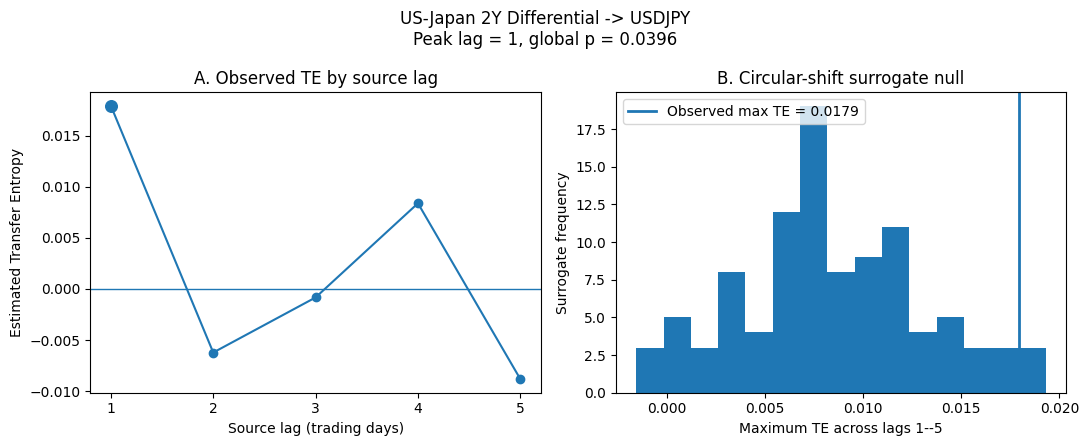

Saved: ../figures/usjp_usdjpy_te_lag_surrogate.png


In [42]:
# ============================================================
# US-JP -> USDJPY TE lag profile and surrogate inference
# ============================================================

lags = focus_te_by_lag["Lag"].to_numpy()
te_values = focus_te_by_lag["TE"].to_numpy()

surrogate_maxima = focus_te[
    "surrogate_maxima"
]

observed_max = focus_te[
    "max_TE"
]

peak_lag = focus_te[
    "peak_lag"
]

global_p = focus_te[
    "global_pvalue"
]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(11, 4.5)
)

# ------------------------------------------------------------
# Panel A: observed TE by lag
# ------------------------------------------------------------

axes[0].plot(
    lags,
    te_values,
    marker="o"
)

axes[0].axhline(
    0,
    linewidth=1
)

axes[0].scatter(
    [peak_lag],
    [observed_max],
    s=70,
    zorder=3
)

axes[0].set_xticks(
    TE_LAGS
)

axes[0].set_xlabel(
    "Source lag (trading days)"
)

axes[0].set_ylabel(
    "Estimated Transfer Entropy"
)

axes[0].set_title(
    "A. Observed TE by source lag"
)

# ------------------------------------------------------------
# Panel B: surrogate maximum distribution
# ------------------------------------------------------------

axes[1].hist(
    surrogate_maxima,
    bins=15
)

axes[1].axvline(
    observed_max,
    linewidth=2,
    label=(
        f"Observed max TE = "
        f"{observed_max:.4f}"
    )
)

axes[1].set_xlabel(
    "Maximum TE across lags 1--5"
)

axes[1].set_ylabel(
    "Surrogate frequency"
)

axes[1].set_title(
    "B. Circular-shift surrogate null"
)

axes[1].legend()

fig.suptitle(
    "US-Japan 2Y Differential -> USDJPY\n"
    f"Peak lag = {peak_lag}, "
    f"global p = {global_p:.4f}"
)

fig.tight_layout()

fig.savefig(
    FOCUS_FIGURE_FILE,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Saved: {FOCUS_FIGURE_FILE}"
)

In [43]:
FOCUS_FIGURE_PDF = (
    FIGURE_DIR
    / "usjp_usdjpy_te_lag_surrogate.pdf"
)

fig.savefig(
    FOCUS_FIGURE_PDF,
    bbox_inches="tight"
)

print(
    f"Saved: {FOCUS_FIGURE_PDF}"
)

Saved: ../figures/usjp_usdjpy_te_lag_surrogate.pdf


**Full-sample interpretation.**

**RQ1.** The full-sample results provide limited evidence that source-market
volatility shocks contain incremental information for subsequent FX volatility
shocks. Linear GC does not reject the null in either direction for any of the
four channels at the 5% level. TE identifies one source-to-FX relationship:
US--Japan 2Y yield-differential volatility shocks to USDJPY volatility shocks
(\(p=0.0396\)), with the maximum estimated TE occurring at a one-day source
delay. No reverse USDJPY-to-US--Japan 2Y relationship is detected. The remaining
three channels are statistically undetected in both directions under the
pre-specified 5% criterion. The US--Germany 2Y to EURUSD direction is relatively
close to the threshold under both GC (\(p=0.0869\)) and TE (\(p=0.0693\)), but
neither test rejects its null. Similarly, the reverse AUDUSD-to-Gold direction
is close to the threshold under GC (\(p=0.0549\)) but is not supported by TE
(\(p=0.7624\)). There is therefore no full-sample evidence of bidirectional
transmission. These results describe directional predictive dependence rather
than structural causality.

**RQ2.** The main GC--TE disagreement occurs for the US--Japan 2Y to USDJPY
channel. GC provides no evidence of linear incremental predictability
(\(p=0.8932\)), whereas the maximum-statistic TE test detects significant
directional information transfer (\(p=0.0396\)). This pattern is consistent with
the nonlinear synthetic DGPs in Chapter 5, where TE can detect directional
dependence that is missed by linear GC. It does not, however, establish that the
empirical US--Japan 2Y--USDJPY relationship follows a particular nonlinear
functional form. The reverse AUDUSD-to-Gold direction shows the opposite type
of method disagreement: GC is close to, but does not cross, the 5% threshold,
while TE provides little evidence of directional dependence. This is treated as
a method disagreement rather than evidence in favour of either method. Overall,
the full-sample evidence suggests that GC and TE need not provide identical
signals, motivating the subsequent conditional and state-dependent analysis.

## 9. Conditional Granger Causality with DXY

Conditional GC tests whether the source retains incremental linear predictive
information after controlling for broad dollar-market volatility.

For each channel and direction, the common lag order is re-selected by AIC over
\(p=1,\ldots,5\). The target, source, and DXY volatility shocks enter with the
same selected lag order.

The joint null tests whether all lagged source coefficients are zero. DXY is
included as a common-factor control and is not itself the hypothesis of interest.

In [44]:
# ============================================================
# Conditional GC helper: build regression design
# ============================================================

def build_conditional_gc_design(y, x, z, p):
    """
    Build the conditional GC regression:

        Y_t ~ Y_{t-1:t-p}
              + X_{t-1:t-p}
              + Z_{t-1:t-p}

    using the same lag order p for Y, X and Z.
    """

    df = pd.DataFrame({
        "Y": np.asarray(y, dtype=float),
        "X": np.asarray(x, dtype=float),
        "Z": np.asarray(z, dtype=float),
    })

    for lag in range(1, p + 1):

        df[f"Y_lag{lag}"] = df["Y"].shift(lag)
        df[f"X_lag{lag}"] = df["X"].shift(lag)
        df[f"Z_lag{lag}"] = df["Z"].shift(lag)

    df = df.dropna()

    y_reg = df["Y"]

    regressors = (
        [f"Y_lag{i}" for i in range(1, p + 1)]
        + [f"X_lag{i}" for i in range(1, p + 1)]
        + [f"Z_lag{i}" for i in range(1, p + 1)]
    )

    X_reg = sm.add_constant(
        df[regressors],
        has_constant="add"
    )

    return y_reg, X_reg

In [45]:
# ============================================================
# Select conditional GC lag order by AIC
# ============================================================

def select_conditional_gc_lag_aic(
    y,
    x,
    z,
    max_lag=GC_MAX_LAG,
):
    """
    Select the common lag order p by minimum AIC over 1,...,max_lag.
    """

    rows = []

    for p in range(1, max_lag + 1):

        y_reg, X_reg = build_conditional_gc_design(
            y=y,
            x=x,
            z=z,
            p=p,
        )

        model = sm.OLS(
            y_reg,
            X_reg
        ).fit()

        rows.append({
            "order": p,
            "aic": model.aic,
        })

    aic_table = pd.DataFrame(rows)

    best_order = int(
        aic_table.loc[
            aic_table["aic"].idxmin(),
            "order"
        ]
    )

    return best_order, aic_table

In [46]:
# ============================================================
# Run one conditional GC direction
# ============================================================

def run_conditional_gc_direction(
    x,
    y,
    z,
    direction,
    max_lag=GC_MAX_LAG,
    alpha=ALPHA,
):
    """
    Conditional linear GC for one direction.

    1. Re-select common p by AIC.
    2. Fit Y on lags of Y, X and DXY control Z.
    3. Jointly test whether all lagged X coefficients are zero.
    """

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    z = np.asarray(z, dtype=float)

    if not (len(x) == len(y) == len(z)):
        raise ValueError(
            "X, Y and Z must have equal length."
        )

    # --------------------------------------------------------
    # 1. Re-select p under the conditional specification
    # --------------------------------------------------------

    selected_order, aic_table = (
        select_conditional_gc_lag_aic(
            y=y,
            x=x,
            z=z,
            max_lag=max_lag,
        )
    )

    # --------------------------------------------------------
    # 2. Fit selected conditional model
    # --------------------------------------------------------

    y_reg, X_reg = build_conditional_gc_design(
        y=y,
        x=x,
        z=z,
        p=selected_order,
    )

    model = sm.OLS(
        y_reg,
        X_reg
    ).fit()

    # --------------------------------------------------------
    # 3. Joint test:
    #    H0: beta_1 = ... = beta_p = 0
    # --------------------------------------------------------

    x_lag_cols = [
        f"X_lag{i}"
        for i in range(
            1,
            selected_order + 1
        )
    ]

    restriction = np.zeros(
        (
            selected_order,
            len(model.params)
        )
    )

    param_names = list(
        model.params.index
    )

    for row, col in enumerate(
        x_lag_cols
    ):
        restriction[
            row,
            param_names.index(col)
        ] = 1.0

    f_test = model.f_test(
        restriction
    )

    f_stat = float(
        np.asarray(
            f_test.fvalue
        ).squeeze()
    )

    conditional_pvalue = float(
        np.asarray(
            f_test.pvalue
        ).squeeze()
    )

    return {
        "direction": direction,
        "selected_p": selected_order,
        "F_stat": f_stat,
        "conditional_pvalue": conditional_pvalue,
        "significant": (
            conditional_pvalue < alpha
        ),
        "aic_table": aic_table,
        "model": model,
    }

In [47]:
# ============================================================
# Conditional GC: all channels, both directions
# ============================================================

conditional_gc_results = []
conditional_gc_details = {}

for channel_name, samples in channel_data.items():

    data = samples["conditional"]

    x = data["X"].to_numpy()
    y = data["Y"].to_numpy()
    z = data["Z"].to_numpy()

    print("=" * 70)
    print(channel_name)

    # X -> Y
    result_xy = run_conditional_gc_direction(
        x=x,
        y=y,
        z=z,
        direction="X->Y",
    )

    # Y -> X
    result_yx = run_conditional_gc_direction(
        x=y,
        y=x,
        z=z,
        direction="Y->X",
    )

    conditional_gc_details[channel_name] = {
        "X->Y": result_xy,
        "Y->X": result_yx,
    }

    for result in [
        result_xy,
        result_yx
    ]:

        conditional_gc_results.append({
            "Channel": channel_name,
            "Direction": result["direction"],
            "N conditional": len(data),
            "Conditional selected p": result["selected_p"],
            "Conditional F statistic": result["F_stat"],
            "Conditional GC p-value": result["conditional_pvalue"],
            "Conditional GC significant": result["significant"],
        })

print("Conditional GC complete.")

US-DE 2Y -> EURUSD
US-JP 2Y -> USDJPY
Gold -> AUDUSD
Brent -> USDCAD
Conditional GC complete.


In [48]:
# ============================================================
# Conditional GC summary
# ============================================================

conditional_gc_df = pd.DataFrame(
    conditional_gc_results
)

conditional_gc_df

,Channel,Direction,N conditional,Conditional selected p,Conditional F statistic,Conditional GC p-value,Conditional GC significant
0,US-DE 2Y -> EURUSD,X->Y,2168,1,2.7172,0.0994,False
1,US-DE 2Y -> EURUSD,Y->X,2168,1,2.0029,0.1571,False
2,US-JP 2Y -> USDJPY,X->Y,2009,1,0.0746,0.7848,False
3,US-JP 2Y -> USDJPY,Y->X,2009,2,1.4332,0.2388,False
4,Gold -> AUDUSD,X->Y,2579,2,0.5001,0.6066,False
5,Gold -> AUDUSD,Y->X,2579,1,0.7942,0.3729,False
6,Brent -> USDCAD,X->Y,2563,1,0.6711,0.4128,False
7,Brent -> USDCAD,Y->X,2563,1,0.2538,0.6145,False


In [49]:
# ============================================================
# Unconditional vs conditional GC
# ============================================================

gc_unconditional = gc_results_df[
    [
        "Channel",
        "Direction",
        "Selected p",
        "Global p-value",
        "Significant",
    ]
].copy()

gc_unconditional = gc_unconditional.rename(
    columns={
        "Selected p": "Unconditional selected p",
        "Global p-value": "Unconditional GC p-value",
        "Significant": "Unconditional GC significant",
    }
)

gc_conditioning_comparison = (
    gc_unconditional.merge(
        conditional_gc_df,
        on=[
            "Channel",
            "Direction"
        ],
        how="inner",
    )
)

gc_conditioning_comparison

,Channel,Direction,Unconditional selected p,Unconditional GC p-value,Unconditional GC significant,N conditional,Conditional selected p,Conditional F statistic,Conditional GC p-value,Conditional GC significant
0,US-DE 2Y -> EURUSD,X->Y,1,0.0869,False,2168,1,2.7172,0.0994,False
1,US-DE 2Y -> EURUSD,Y->X,1,0.3581,False,2168,1,2.0029,0.1571,False
2,US-JP 2Y -> USDJPY,X->Y,1,0.8932,False,2009,1,0.0746,0.7848,False
3,US-JP 2Y -> USDJPY,Y->X,2,0.4092,False,2009,2,1.4332,0.2388,False
4,Gold -> AUDUSD,X->Y,1,0.9221,False,2579,2,0.5001,0.6066,False
5,Gold -> AUDUSD,Y->X,1,0.0549,False,2579,1,0.7942,0.3729,False
6,Brent -> USDCAD,X->Y,1,0.3877,False,2563,1,0.6711,0.4128,False
7,Brent -> USDCAD,Y->X,1,0.9532,False,2563,1,0.2538,0.6145,False


## 10. Conditional Transfer Entropy with DXY

Conditional TE tests whether directional information remains after controlling
for broad dollar-market volatility.

The baseline conditioning set is

\[
(Y_{t-1}, Z_{t-1}, Z_{t-2}),
\]

so the target-history embedding is \(m=1\) and the DXY embedding is \(m_Z=2\).

The remaining TE settings are unchanged: \(k=10\), source delays
\(\ell=1,\ldots,5\), and \(B=100\) circular-shift surrogates. Significance is
based on the maximum TE statistic across the five candidate source delays.

In [50]:
# ============================================================
# Conditional TE helper: construct aligned vectors
# ============================================================

def build_conditional_te_vectors(
    x,
    y,
    z,
    source_lag,
    m=TE_M,
    m_z=TE_MZ,
):
    """
    Construct conditional TE vectors for

        I(Y_t ; X_{t-lag} |
          Y_{t-1:t-m},
          Z_{t-1:t-m_z})
    """

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    z = np.asarray(z, dtype=float)

    if not (len(x) == len(y) == len(z)):
        raise ValueError("X, Y and Z must have equal length.")

    start = max(
        source_lag,
        m,
        m_z,
    )

    y_t = y[start:]

    x_source = x[
        start - source_lag:
        len(x) - source_lag
    ]

    y_history = np.column_stack([
        y[start - lag:len(y) - lag]
        for lag in range(1, m + 1)
    ])

    z_history = np.column_stack([
        z[start - lag:len(z) - lag]
        for lag in range(1, m_z + 1)
    ])

    conditioning = np.column_stack([
        y_history,
        z_history,
    ])

    return y_t, conditioning, x_source

In [51]:
# ============================================================
# Conditional TE at one source lag
# ============================================================

def conditional_te_at_lag(
    x,
    y,
    z,
    lag,
    k=TE_K,
    m=TE_M,
    m_z=TE_MZ,
):
    """
    Estimate

        I(Y_t ; X_{t-lag} |
          Y history, Z history)
    """

    y_t, conditioning, x_source = (
        build_conditional_te_vectors(
            x=x,
            y=y,
            z=z,
            source_lag=lag,
            m=m,
            m_z=m_z,
        )
    )

    return ksg_cmi(
        y_t=y_t,
        y_history=conditioning,
        x_source=x_source,
        k=k,
    )

In [52]:
# ============================================================
# Run one conditional TE direction
# ============================================================

def run_conditional_te_direction(
    x,
    y,
    z,
    direction,
    lags=TE_LAGS,
    k=TE_K,
    m=TE_M,
    m_z=TE_MZ,
    n_surrogates=TE_SURROGATES,
    alpha=ALPHA,
    seed=20000,
):
    """
    Conditional TE for one direction.

    1. Estimate conditional TE at lags 1--5.
    2. Record observed maximum TE and peak lag.
    3. Circular-shift only the source X.
    4. For each surrogate, retain maximum TE across lags.
    5. Compute one global maximum-statistic p-value.
    """

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    z = np.asarray(z, dtype=float)

    if not (len(x) == len(y) == len(z)):
        raise ValueError("X, Y and Z must have equal length.")

    rng = np.random.default_rng(seed)

    # --------------------------------------------------------
    # 1. Observed conditional TE by lag
    # --------------------------------------------------------

    te_by_lag = {
        lag: conditional_te_at_lag(
            x=x,
            y=y,
            z=z,
            lag=lag,
            k=k,
            m=m,
            m_z=m_z,
        )
        for lag in lags
    }

    peak_lag = max(
        te_by_lag,
        key=te_by_lag.get
    )

    observed_max = te_by_lag[
        peak_lag
    ]

    # --------------------------------------------------------
    # 2. Circular-shift surrogate maxima
    # --------------------------------------------------------

    n = len(x)

    surrogate_maxima = np.empty(
        n_surrogates
    )

    for b in range(n_surrogates):

        shift = int(
            rng.integers(1, n)
        )

        x_shifted = np.roll(
            x,
            shift
        )

        surrogate_maxima[b] = max(
            conditional_te_at_lag(
                x=x_shifted,
                y=y,
                z=z,
                lag=lag,
                k=k,
                m=m,
                m_z=m_z,
            )
            for lag in lags
        )

    # --------------------------------------------------------
    # 3. Global maximum-statistic p-value
    # --------------------------------------------------------

    global_pvalue = (
        1
        + np.sum(
            surrogate_maxima >= observed_max
        )
    ) / (
        n_surrogates + 1
    )

    return {
        "direction": direction,
        "m": m,
        "m_z": m_z,
        "TE_by_lag": te_by_lag,
        "max_TE": float(observed_max),
        "peak_lag": int(peak_lag),
        "global_pvalue": float(global_pvalue),
        "significant": bool(
            global_pvalue < alpha
        ),
        "surrogate_maxima": surrogate_maxima,
    }

In [53]:
# ============================================================
# Baseline conditional TE: all channels, both directions
# ============================================================

conditional_te_results = []
conditional_te_details = {}

seed_counter = 20000

for channel_name, samples in channel_data.items():

    data = samples["conditional"]

    x = data["X"].to_numpy()
    y = data["Y"].to_numpy()
    z = data["Z"].to_numpy()

    print("=" * 70)
    print(channel_name)

    # --------------------------------------------------------
    # X -> Y
    # --------------------------------------------------------

    print("Running conditional X -> Y ...")

    result_xy = run_conditional_te_direction(
        x=x,
        y=y,
        z=z,
        direction="X->Y",
        seed=seed_counter,
    )

    seed_counter += 1

    # --------------------------------------------------------
    # Y -> X
    # --------------------------------------------------------

    print("Running conditional Y -> X ...")

    result_yx = run_conditional_te_direction(
        x=y,
        y=x,
        z=z,
        direction="Y->X",
        seed=seed_counter,
    )

    seed_counter += 1

    conditional_te_details[
        channel_name
    ] = {
        "X->Y": result_xy,
        "Y->X": result_yx,
    }

    for result in [
        result_xy,
        result_yx
    ]:

        conditional_te_results.append({
            "Channel": channel_name,
            "Direction": result["direction"],
            "N conditional": len(data),
            "m": result["m"],
            "m_Z": result["m_z"],
            "Conditional Max TE": result["max_TE"],
            "Conditional peak lag": result["peak_lag"],
            "Conditional TE p-value": result["global_pvalue"],
            "Conditional TE significant": result["significant"],
        })

    print("Done.\n")

US-DE 2Y -> EURUSD
Running conditional X -> Y ...
Running conditional Y -> X ...
Done.

US-JP 2Y -> USDJPY
Running conditional X -> Y ...
Running conditional Y -> X ...
Done.

Gold -> AUDUSD
Running conditional X -> Y ...
Running conditional Y -> X ...
Done.

Brent -> USDCAD
Running conditional X -> Y ...
Running conditional Y -> X ...
Done.



In [54]:
# ============================================================
# Baseline conditional TE summary
# ============================================================

conditional_te_df = pd.DataFrame(
    conditional_te_results
)

conditional_te_df

,Channel,Direction,N conditional,m,m_Z,Conditional Max TE,Conditional peak lag,Conditional TE p-value,Conditional TE significant
0,US-DE 2Y -> EURUSD,X->Y,2168,1,2,0.0107,4,0.1287,False
1,US-DE 2Y -> EURUSD,Y->X,2168,1,2,0.0065,3,0.3762,False
2,US-JP 2Y -> USDJPY,X->Y,2009,1,2,0.0068,2,0.4752,False
3,US-JP 2Y -> USDJPY,Y->X,2009,1,2,0.0093,4,0.2772,False
4,Gold -> AUDUSD,X->Y,2579,1,2,0.0049,3,0.5446,False
5,Gold -> AUDUSD,Y->X,2579,1,2,0.0056,5,0.3762,False
6,Brent -> USDCAD,X->Y,2563,1,2,0.0079,4,0.2772,False
7,Brent -> USDCAD,Y->X,2563,1,2,0.0024,4,0.8218,False


In [55]:
# ============================================================
# Conditional TE by source lag
# ============================================================

conditional_te_lag_rows = []

for channel_name, directions in (
    conditional_te_details.items()
):

    for direction, result in (
        directions.items()
    ):

        for lag, te_value in (
            result["TE_by_lag"].items()
        ):

            conditional_te_lag_rows.append({
                "Channel": channel_name,
                "Direction": direction,
                "Lag": lag,
                "Conditional TE": te_value,
                "Peak": (
                    lag == result["peak_lag"]
                ),
            })

conditional_te_by_lag_df = pd.DataFrame(
    conditional_te_lag_rows
)

conditional_te_by_lag_df

,Channel,Direction,Lag,Conditional TE,Peak
0,US-DE 2Y -> EURUSD,X->Y,1,-0.0002,False
1,US-DE 2Y -> EURUSD,X->Y,2,-0.0054,False
2,US-DE 2Y -> EURUSD,X->Y,3,-0.0021,False
3,US-DE 2Y -> EURUSD,X->Y,4,0.0107,True
4,US-DE 2Y -> EURUSD,X->Y,5,0.0025,False
5,US-DE 2Y -> EURUSD,Y->X,1,-0.0039,False
6,US-DE 2Y -> EURUSD,Y->X,2,-0.0022,False
7,US-DE 2Y -> EURUSD,Y->X,3,0.0065,True
8,US-DE 2Y -> EURUSD,Y->X,4,-0.0051,False
9,US-DE 2Y -> EURUSD,Y->X,5,0.0016,False


In [56]:
# ============================================================
# Unconditional vs conditional TE
# ============================================================

te_unconditional = te_results_df[
    [
        "Channel",
        "Direction",
        "Max TE",
        "Peak lag",
        "Global p-value",
        "Significant",
    ]
].copy()

te_unconditional = te_unconditional.rename(
    columns={
        "Max TE": "Unconditional Max TE",
        "Peak lag": "Unconditional peak lag",
        "Global p-value": "Unconditional TE p-value",
        "Significant": "Unconditional TE significant",
    }
)

te_conditioning_comparison = (
    te_unconditional.merge(
        conditional_te_df[
            [
                "Channel",
                "Direction",
                "N conditional",
                "Conditional Max TE",
                "Conditional peak lag",
                "Conditional TE p-value",
                "Conditional TE significant",
            ]
        ],
        on=[
            "Channel",
            "Direction"
        ],
        how="inner",
    )
)

te_conditioning_comparison

,Channel,Direction,Unconditional Max TE,Unconditional peak lag,Unconditional TE p-value,Unconditional TE significant,N conditional,Conditional Max TE,Conditional peak lag,Conditional TE p-value,Conditional TE significant
0,US-DE 2Y -> EURUSD,X->Y,0.0165,4,0.0693,False,2168,0.0107,4,0.1287,False
1,US-DE 2Y -> EURUSD,Y->X,0.0137,3,0.1287,False,2168,0.0065,3,0.3762,False
2,US-JP 2Y -> USDJPY,X->Y,0.0179,1,0.0396,True,2009,0.0068,2,0.4752,False
3,US-JP 2Y -> USDJPY,Y->X,0.0135,4,0.2475,False,2009,0.0093,4,0.2772,False
4,Gold -> AUDUSD,X->Y,0.0136,3,0.1881,False,2579,0.0049,3,0.5446,False
5,Gold -> AUDUSD,Y->X,0.0045,4,0.7624,False,2579,0.0056,5,0.3762,False
6,Brent -> USDCAD,X->Y,0.0059,2,0.6436,False,2563,0.0079,4,0.2772,False
7,Brent -> USDCAD,Y->X,0.0039,4,0.7426,False,2563,0.0024,4,0.8218,False


In [57]:
# ============================================================
# Conditional TE sanity checks
# ============================================================

assert len(
    conditional_te_df
) == len(CHANNELS) * 2

assert (
    conditional_te_df["m"] == TE_M
).all()

assert (
    conditional_te_df["m_Z"] == TE_MZ
).all()

assert conditional_te_df[
    "Conditional peak lag"
].isin(TE_LAGS).all()

assert conditional_te_df[
    "Conditional TE p-value"
].between(0, 1).all()

for channel_name, directions in (
    conditional_te_details.items()
):

    for direction, result in directions.items():

        assert len(
            result["surrogate_maxima"]
        ) == TE_SURROGATES

        assert set(
            result["TE_by_lag"].keys()
        ) == set(TE_LAGS)

print("Conditional TE checks passed.")

Conditional TE checks passed.


### Conditional-TE embedding sensitivity

The baseline conditional-TE specification remains fixed at
\((m,m_Z)=(1,2)\), as motivated by the synthetic calibration.

Three pre-specified nearby embeddings are used as sensitivity checks:

\[
(m,m_Z)\in\{(1,1),(1,3),(2,2)\}.
\]

These specifications are not alternative models selected according to
statistical significance. They are used only to assess whether the baseline
conditional-TE conclusion is sensitive to reasonable changes in the target
and DXY conditioning histories.

In [58]:
# ============================================================
# Pre-specified conditional-TE embedding sensitivity
# ============================================================

CONDITIONAL_TE_SENSITIVITY = [
    (1, 1),
    (1, 3),
    (2, 2),
]

BASELINE_TE_EMBEDDING = (
    TE_M,
    TE_MZ,
)

print(
    "Baseline:",
    BASELINE_TE_EMBEDDING
)

print(
    "Sensitivity:",
    CONDITIONAL_TE_SENSITIVITY
)

Baseline: (1, 2)
Sensitivity: [(1, 1), (1, 3), (2, 2)]


In [59]:
# ============================================================
# Run conditional-TE embedding sensitivity
# ============================================================

conditional_te_sensitivity_results = []
conditional_te_sensitivity_details = {}

seed_counter = 30000

for m_sens, mz_sens in CONDITIONAL_TE_SENSITIVITY:

    specification = (
        f"m={m_sens}, m_Z={mz_sens}"
    )

    print("\n" + "=" * 70)
    print(specification)
    print("=" * 70)

    conditional_te_sensitivity_details[
        (m_sens, mz_sens)
    ] = {}

    for channel_name, samples in channel_data.items():

        data = samples["conditional"]

        x = data["X"].to_numpy()
        y = data["Y"].to_numpy()
        z = data["Z"].to_numpy()

        print(channel_name)

        # ----------------------------------------------------
        # X -> Y
        # ----------------------------------------------------

        result_xy = run_conditional_te_direction(
            x=x,
            y=y,
            z=z,
            direction="X->Y",
            m=m_sens,
            m_z=mz_sens,
            seed=seed_counter,
        )

        seed_counter += 1

        # ----------------------------------------------------
        # Y -> X
        # ----------------------------------------------------

        result_yx = run_conditional_te_direction(
            x=y,
            y=x,
            z=z,
            direction="Y->X",
            m=m_sens,
            m_z=mz_sens,
            seed=seed_counter,
        )

        seed_counter += 1

        conditional_te_sensitivity_details[
            (m_sens, mz_sens)
        ][channel_name] = {
            "X->Y": result_xy,
            "Y->X": result_yx,
        }

        for result in [
            result_xy,
            result_yx,
        ]:

            conditional_te_sensitivity_results.append({
                "Channel": channel_name,
                "Direction": result["direction"],
                "m": m_sens,
                "m_Z": mz_sens,
                "Max TE": result["max_TE"],
                "Peak lag": result["peak_lag"],
                "Global p-value": result["global_pvalue"],
                "Significant": result["significant"],
            })

    print("Done.")


m=1, m_Z=1
US-DE 2Y -> EURUSD
US-JP 2Y -> USDJPY
Gold -> AUDUSD
Brent -> USDCAD
Done.

m=1, m_Z=3
US-DE 2Y -> EURUSD
US-JP 2Y -> USDJPY
Gold -> AUDUSD
Brent -> USDCAD
Done.

m=2, m_Z=2
US-DE 2Y -> EURUSD
US-JP 2Y -> USDJPY
Gold -> AUDUSD
Brent -> USDCAD
Done.


In [60]:
# ============================================================
# Conditional-TE sensitivity summary
# ============================================================

conditional_te_sensitivity_df = pd.DataFrame(
    conditional_te_sensitivity_results
)

conditional_te_sensitivity_df

,Channel,Direction,m,m_Z,Max TE,Peak lag,Global p-value,Significant
0,US-DE 2Y -> EURUSD,X->Y,1,1,0.0023,3,0.9208,False
1,US-DE 2Y -> EURUSD,Y->X,1,1,0.0127,3,0.0495,True
2,US-JP 2Y -> USDJPY,X->Y,1,1,0.0074,4,0.5248,False
3,US-JP 2Y -> USDJPY,Y->X,1,1,0.0148,4,0.0693,False
4,Gold -> AUDUSD,X->Y,1,1,0.0080,5,0.2871,False
5,Gold -> AUDUSD,Y->X,1,1,0.0031,5,0.7921,False
6,Brent -> USDCAD,X->Y,1,1,0.0005,3,0.9703,False
7,Brent -> USDCAD,Y->X,1,1,0.0064,4,0.4455,False
8,US-DE 2Y -> EURUSD,X->Y,1,3,0.0046,4,0.5446,False
9,US-DE 2Y -> EURUSD,Y->X,1,3,0.0072,5,0.2376,False


In [61]:
# ============================================================
# Combine baseline and sensitivity specifications
# ============================================================

baseline_embedding_df = (
    conditional_te_df[
        [
            "Channel",
            "Direction",
            "m",
            "m_Z",
            "Conditional Max TE",
            "Conditional peak lag",
            "Conditional TE p-value",
            "Conditional TE significant",
        ]
    ]
    .rename(
        columns={
            "Conditional Max TE": "Max TE",
            "Conditional peak lag": "Peak lag",
            "Conditional TE p-value": "Global p-value",
            "Conditional TE significant": "Significant",
        }
    )
    .copy()
)

baseline_embedding_df[
    "Specification"
] = "Baseline"

sensitivity_embedding_df = (
    conditional_te_sensitivity_df.copy()
)

sensitivity_embedding_df[
    "Specification"
] = "Sensitivity"

conditional_te_embedding_all = pd.concat(
    [
        baseline_embedding_df,
        sensitivity_embedding_df,
    ],
    ignore_index=True,
)

conditional_te_embedding_all = (
    conditional_te_embedding_all[
        [
            "Channel",
            "Direction",
            "Specification",
            "m",
            "m_Z",
            "Max TE",
            "Peak lag",
            "Global p-value",
            "Significant",
        ]
    ]
)

conditional_te_embedding_all

,Channel,Direction,Specification,m,m_Z,Max TE,Peak lag,Global p-value,Significant
0,US-DE 2Y -> EURUSD,X->Y,Baseline,1,2,0.0107,4,0.1287,False
1,US-DE 2Y -> EURUSD,Y->X,Baseline,1,2,0.0065,3,0.3762,False
2,US-JP 2Y -> USDJPY,X->Y,Baseline,1,2,0.0068,2,0.4752,False
3,US-JP 2Y -> USDJPY,Y->X,Baseline,1,2,0.0093,4,0.2772,False
4,Gold -> AUDUSD,X->Y,Baseline,1,2,0.0049,3,0.5446,False
5,Gold -> AUDUSD,Y->X,Baseline,1,2,0.0056,5,0.3762,False
6,Brent -> USDCAD,X->Y,Baseline,1,2,0.0079,4,0.2772,False
7,Brent -> USDCAD,Y->X,Baseline,1,2,0.0024,4,0.8218,False
8,US-DE 2Y -> EURUSD,X->Y,Sensitivity,1,1,0.0023,3,0.9208,False
9,US-DE 2Y -> EURUSD,Y->X,Sensitivity,1,1,0.0127,3,0.0495,True


In [62]:
# ============================================================
# Compact embedding sensitivity table: global p-values
# ============================================================

embedding_pvalue_table = (
    conditional_te_embedding_all
    .pivot_table(
        index=[
            "Channel",
            "Direction",
        ],
        columns=[
            "m",
            "m_Z",
        ],
        values="Global p-value",
        aggfunc="first",
    )
)

embedding_pvalue_table.columns = [
    f"p(m={m},m_Z={mz})"
    for m, mz in embedding_pvalue_table.columns
]

embedding_pvalue_table = (
    embedding_pvalue_table
    .reset_index()
)

embedding_pvalue_table

,Channel,Direction,"p(m=1,m_Z=1)","p(m=1,m_Z=2)","p(m=1,m_Z=3)","p(m=2,m_Z=2)"
0,Brent -> USDCAD,X->Y,0.9703,0.2772,0.8416,0.1089
1,Brent -> USDCAD,Y->X,0.4455,0.8218,0.6931,0.9406
2,Gold -> AUDUSD,X->Y,0.2871,0.5446,0.3564,0.1386
3,Gold -> AUDUSD,Y->X,0.7921,0.3762,0.2673,0.2970
4,US-DE 2Y -> EURUSD,X->Y,0.9208,0.1287,0.5446,0.9703
5,US-DE 2Y -> EURUSD,Y->X,0.0495,0.3762,0.2376,0.7327
6,US-JP 2Y -> USDJPY,X->Y,0.5248,0.4752,0.5347,0.0792
7,US-JP 2Y -> USDJPY,Y->X,0.0693,0.2772,0.2772,0.9109


In [63]:
# ============================================================
# Stability of significance conclusion
# ============================================================

stability_rows = []

for (
    channel_name,
    direction
), group in conditional_te_embedding_all.groupby(
    [
        "Channel",
        "Direction",
    ]
):

    baseline_row = group[
        group["Specification"] == "Baseline"
    ].iloc[0]

    baseline_significant = bool(
        baseline_row["Significant"]
    )

    all_same = (
        group["Significant"]
        == baseline_significant
    ).all()

    stability_rows.append({
        "Channel": channel_name,
        "Direction": direction,
        "Baseline significant": baseline_significant,
        "Stable across embeddings": bool(all_same),
        "Minimum p-value": group[
            "Global p-value"
        ].min(),
        "Maximum p-value": group[
            "Global p-value"
        ].max(),
    })

conditional_te_stability_df = pd.DataFrame(
    stability_rows
)

conditional_te_stability_df

,Channel,Direction,Baseline significant,Stable across embeddings,Minimum p-value,Maximum p-value
0,Brent -> USDCAD,X->Y,False,True,0.1089,0.9703
1,Brent -> USDCAD,Y->X,False,True,0.4455,0.9406
2,Gold -> AUDUSD,X->Y,False,True,0.1386,0.5446
3,Gold -> AUDUSD,Y->X,False,True,0.2673,0.7921
4,US-DE 2Y -> EURUSD,X->Y,False,True,0.1287,0.9703
5,US-DE 2Y -> EURUSD,Y->X,False,False,0.0495,0.7327
6,US-JP 2Y -> USDJPY,X->Y,False,True,0.0792,0.5347
7,US-JP 2Y -> USDJPY,Y->X,False,True,0.0693,0.9109


In [64]:
# ============================================================
# Focus: US-Japan 2Y -> USDJPY
# ============================================================

usjp_embedding_check = (
    conditional_te_embedding_all[
        (
            conditional_te_embedding_all[
                "Channel"
            ] == "US-JP 2Y -> USDJPY"
        )
        &
        (
            conditional_te_embedding_all[
                "Direction"
            ] == "X->Y"
        )
    ]
    [
        [
            "Specification",
            "m",
            "m_Z",
            "Max TE",
            "Peak lag",
            "Global p-value",
            "Significant",
        ]
    ]
    .sort_values(
        [
            "m",
            "m_Z",
        ]
    )
)

usjp_embedding_check

,Specification,m,m_Z,Max TE,Peak lag,Global p-value,Significant
10,Sensitivity,1,1,0.0074,4,0.5248,False
2,Baseline,1,2,0.0068,2,0.4752,False
18,Sensitivity,1,3,0.0056,2,0.5347,False
26,Sensitivity,2,2,0.0105,5,0.0792,False


### Common-factor attenuation

The unconditional and DXY-conditioned results are compared to assess whether
the detected directional evidence survives control for broad dollar-market
volatility.

The main classification is based on the pre-specified 5% significance level:

- **Persists:** significant before and after conditioning.
- **Disappears:** significant unconditionally but not after conditioning.
- **Appears after conditioning:** insignificant unconditionally but significant conditionally.
- **Undetected in both:** insignificant under both specifications.

Changes in p-values are also reported descriptively as evidence strengthening
or weakening, but are not interpreted as changes in structural causal strength.

In [65]:
# ============================================================
# Common-factor comparison helpers
# ============================================================

def classify_detection(
    unconditional_sig,
    conditional_sig,
):
    """
    Classify the change in statistical detection after DXY conditioning.
    """

    if unconditional_sig and conditional_sig:
        return "Persists"

    if unconditional_sig and not conditional_sig:
        return "Disappears"

    if not unconditional_sig and conditional_sig:
        return "Appears after conditioning"

    return "Undetected in both"


def classify_evidence_shift(
    p_unconditional,
    p_conditional,
    tolerance=0.02,
):
    """
    Descriptive change in p-value.

    This is not interpreted as a change in structural effect size.
    """

    change = p_conditional - p_unconditional

    if abs(change) <= tolerance:
        return "Little change"

    if change > 0:
        return "Weaker"

    return "Stronger"

In [66]:
# ============================================================
# GC: unconditional vs DXY-conditioned
# ============================================================

gc_common_factor = (
    gc_conditioning_comparison[
        [
            "Channel",
            "Direction",
            "Unconditional selected p",
            "Unconditional GC p-value",
            "Unconditional GC significant",
            "Conditional selected p",
            "Conditional GC p-value",
            "Conditional GC significant",
        ]
    ]
    .copy()
)

gc_common_factor["GC detection change"] = (
    gc_common_factor.apply(
        lambda row: classify_detection(
            row["Unconditional GC significant"],
            row["Conditional GC significant"],
        ),
        axis=1,
    )
)

gc_common_factor["GC evidence shift"] = (
    gc_common_factor.apply(
        lambda row: classify_evidence_shift(
            row["Unconditional GC p-value"],
            row["Conditional GC p-value"],
        ),
        axis=1,
    )
)

gc_common_factor

,Channel,Direction,Unconditional selected p,Unconditional GC p-value,Unconditional GC significant,Conditional selected p,Conditional GC p-value,Conditional GC significant,GC detection change,GC evidence shift
0,US-DE 2Y -> EURUSD,X->Y,1,0.0869,False,1,0.0994,False,Undetected in both,Little change
1,US-DE 2Y -> EURUSD,Y->X,1,0.3581,False,1,0.1571,False,Undetected in both,Stronger
2,US-JP 2Y -> USDJPY,X->Y,1,0.8932,False,1,0.7848,False,Undetected in both,Stronger
3,US-JP 2Y -> USDJPY,Y->X,2,0.4092,False,2,0.2388,False,Undetected in both,Stronger
4,Gold -> AUDUSD,X->Y,1,0.9221,False,2,0.6066,False,Undetected in both,Stronger
5,Gold -> AUDUSD,Y->X,1,0.0549,False,1,0.3729,False,Undetected in both,Weaker
6,Brent -> USDCAD,X->Y,1,0.3877,False,1,0.4128,False,Undetected in both,Weaker
7,Brent -> USDCAD,Y->X,1,0.9532,False,1,0.6145,False,Undetected in both,Stronger


In [67]:
# ============================================================
# TE: unconditional vs DXY-conditioned
# ============================================================

te_common_factor = (
    te_conditioning_comparison[
        [
            "Channel",
            "Direction",
            "Unconditional Max TE",
            "Unconditional peak lag",
            "Unconditional TE p-value",
            "Unconditional TE significant",
            "Conditional Max TE",
            "Conditional peak lag",
            "Conditional TE p-value",
            "Conditional TE significant",
        ]
    ]
    .copy()
)

te_common_factor["TE detection change"] = (
    te_common_factor.apply(
        lambda row: classify_detection(
            row["Unconditional TE significant"],
            row["Conditional TE significant"],
        ),
        axis=1,
    )
)

te_common_factor["TE evidence shift"] = (
    te_common_factor.apply(
        lambda row: classify_evidence_shift(
            row["Unconditional TE p-value"],
            row["Conditional TE p-value"],
        ),
        axis=1,
    )
)

te_common_factor["Max TE change"] = (
    te_common_factor["Conditional Max TE"]
    - te_common_factor["Unconditional Max TE"]
)

te_common_factor

,Channel,Direction,Unconditional Max TE,Unconditional peak lag,Unconditional TE p-value,Unconditional TE significant,Conditional Max TE,Conditional peak lag,Conditional TE p-value,Conditional TE significant,TE detection change,TE evidence shift,Max TE change
0,US-DE 2Y -> EURUSD,X->Y,0.0165,4,0.0693,False,0.0107,4,0.1287,False,Undetected in both,Weaker,-0.0059
1,US-DE 2Y -> EURUSD,Y->X,0.0137,3,0.1287,False,0.0065,3,0.3762,False,Undetected in both,Weaker,-0.0073
2,US-JP 2Y -> USDJPY,X->Y,0.0179,1,0.0396,True,0.0068,2,0.4752,False,Disappears,Weaker,-0.0111
3,US-JP 2Y -> USDJPY,Y->X,0.0135,4,0.2475,False,0.0093,4,0.2772,False,Undetected in both,Weaker,-0.0042
4,Gold -> AUDUSD,X->Y,0.0136,3,0.1881,False,0.0049,3,0.5446,False,Undetected in both,Weaker,-0.0087
5,Gold -> AUDUSD,Y->X,0.0045,4,0.7624,False,0.0056,5,0.3762,False,Undetected in both,Stronger,0.0010
6,Brent -> USDCAD,X->Y,0.0059,2,0.6436,False,0.0079,4,0.2772,False,Undetected in both,Stronger,0.0020
7,Brent -> USDCAD,Y->X,0.0039,4,0.7426,False,0.0024,4,0.8218,False,Undetected in both,Weaker,-0.0016


In [68]:
# ============================================================
# Combined GC--TE common-factor table
# ============================================================

common_factor_table = (
    gc_common_factor.merge(
        te_common_factor,
        on=[
            "Channel",
            "Direction",
        ],
        how="inner",
    )
)

common_factor_report = common_factor_table[
    [
        "Channel",
        "Direction",

        "Unconditional GC p-value",
        "Conditional GC p-value",
        "GC detection change",
        "GC evidence shift",

        "Unconditional Max TE",
        "Conditional Max TE",
        "Unconditional TE p-value",
        "Conditional TE p-value",
        "TE detection change",
        "TE evidence shift",

        "Unconditional peak lag",
        "Conditional peak lag",
    ]
].copy()

common_factor_report

,Channel,Direction,Unconditional GC p-value,Conditional GC p-value,GC detection change,GC evidence shift,Unconditional Max TE,Conditional Max TE,Unconditional TE p-value,Conditional TE p-value,TE detection change,TE evidence shift,Unconditional peak lag,Conditional peak lag
0,US-DE 2Y -> EURUSD,X->Y,0.0869,0.0994,Undetected in both,Little change,0.0165,0.0107,0.0693,0.1287,Undetected in both,Weaker,4,4
1,US-DE 2Y -> EURUSD,Y->X,0.3581,0.1571,Undetected in both,Stronger,0.0137,0.0065,0.1287,0.3762,Undetected in both,Weaker,3,3
2,US-JP 2Y -> USDJPY,X->Y,0.8932,0.7848,Undetected in both,Stronger,0.0179,0.0068,0.0396,0.4752,Disappears,Weaker,1,2
3,US-JP 2Y -> USDJPY,Y->X,0.4092,0.2388,Undetected in both,Stronger,0.0135,0.0093,0.2475,0.2772,Undetected in both,Weaker,4,4
4,Gold -> AUDUSD,X->Y,0.9221,0.6066,Undetected in both,Stronger,0.0136,0.0049,0.1881,0.5446,Undetected in both,Weaker,3,3
5,Gold -> AUDUSD,Y->X,0.0549,0.3729,Undetected in both,Weaker,0.0045,0.0056,0.7624,0.3762,Undetected in both,Stronger,4,5
6,Brent -> USDCAD,X->Y,0.3877,0.4128,Undetected in both,Weaker,0.0059,0.0079,0.6436,0.2772,Undetected in both,Stronger,2,4
7,Brent -> USDCAD,Y->X,0.9532,0.6145,Undetected in both,Stronger,0.0039,0.0024,0.7426,0.8218,Undetected in both,Weaker,4,4


In [69]:
# ============================================================
# Save common-factor attenuation table
# ============================================================

COMMON_FACTOR_TABLE_FILE = (
    TABLE_DIR
    / "common_factor_gc_te_attenuation.csv"
)

common_factor_report.to_csv(
    COMMON_FACTOR_TABLE_FILE,
    index=False,
)

print(
    f"Saved: {COMMON_FACTOR_TABLE_FILE}"
)

Saved: ../tables/common_factor_gc_te_attenuation.csv


In [70]:
# ============================================================
# Prepare common-factor figure data
# ============================================================

CHANNEL_LABELS = {
    "US-DE 2Y -> EURUSD": "US-DE 2Y / EURUSD",
    "US-JP 2Y -> USDJPY": "US-JP 2Y / USDJPY",
    "Gold -> AUDUSD": "Gold / AUDUSD",
    "Brent -> USDCAD": "Brent / USDCAD",
}

plot_rows = []

for _, row in common_factor_report.iterrows():

    channel = CHANNEL_LABELS[
        row["Channel"]
    ]

    direction = row["Direction"]

    plot_label = (
        f"{channel} | {direction}"
    )

    plot_rows.append({
        "Label": plot_label,

        "GC unconditional": (
            -np.log10(
                row[
                    "Unconditional GC p-value"
                ]
            )
        ),

        "GC conditional": (
            -np.log10(
                row[
                    "Conditional GC p-value"
                ]
            )
        ),

        "TE unconditional": (
            -np.log10(
                row[
                    "Unconditional TE p-value"
                ]
            )
        ),

        "TE conditional": (
            -np.log10(
                row[
                    "Conditional TE p-value"
                ]
            )
        ),
    })

common_factor_plot_df = pd.DataFrame(
    plot_rows
)

common_factor_plot_df

,Label,GC unconditional,GC conditional,TE unconditional,TE conditional
0,US-DE 2Y / EURUSD | X->Y,1.0610,1.0025,1.1592,0.8904
1,US-DE 2Y / EURUSD | Y->X,0.4460,0.8037,0.8904,0.4245
2,US-JP 2Y / USDJPY | X->Y,0.0490,0.1052,1.4023,0.3231
3,US-JP 2Y / USDJPY | Y->X,0.3880,0.6220,0.6064,0.5572
4,Gold / AUDUSD | X->Y,0.0352,0.2171,0.7256,0.2640
5,Gold / AUDUSD | Y->X,1.2606,0.4284,0.1178,0.4245
6,Brent / USDCAD | X->Y,0.4115,0.3843,0.1914,0.5572
7,Brent / USDCAD | Y->X,0.0208,0.2115,0.1293,0.0852


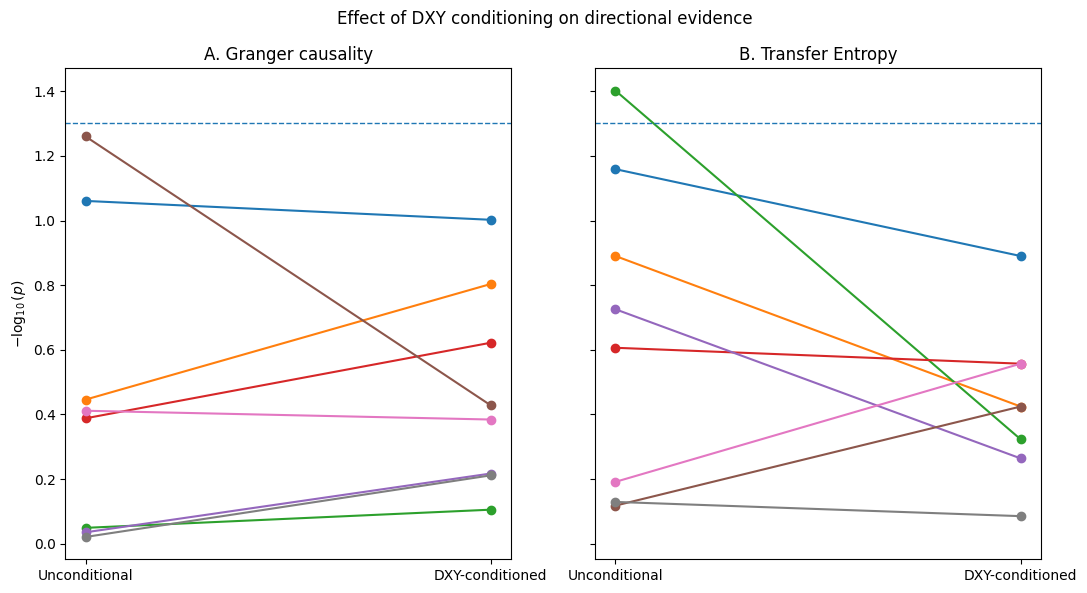

Saved: ../figures/common_factor_gc_te_attenuation.png
Saved: ../figures/common_factor_gc_te_attenuation.pdf


In [71]:
# ============================================================
# Common-factor attenuation figure
# ============================================================

import matplotlib.pyplot as plt

COMMON_FACTOR_FIGURE_PNG = (
    FIGURE_DIR
    / "common_factor_gc_te_attenuation.png"
)

COMMON_FACTOR_FIGURE_PDF = (
    FIGURE_DIR
    / "common_factor_gc_te_attenuation.pdf"
)

threshold = -np.log10(ALPHA)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(11, 6),
    sharey=True,
)

# ------------------------------------------------------------
# Panel A: GC
# ------------------------------------------------------------

for _, row in common_factor_plot_df.iterrows():

    axes[0].plot(
        [0, 1],
        [
            row["GC unconditional"],
            row["GC conditional"],
        ],
        marker="o",
    )

axes[0].axhline(
    threshold,
    linestyle="--",
    linewidth=1,
)

axes[0].set_xticks(
    [0, 1]
)

axes[0].set_xticklabels(
    [
        "Unconditional",
        "DXY-conditioned",
    ]
)

axes[0].set_ylabel(
    r"$-\log_{10}(p)$"
)

axes[0].set_title(
    "A. Granger causality"
)

# ------------------------------------------------------------
# Panel B: TE
# ------------------------------------------------------------

for _, row in common_factor_plot_df.iterrows():

    axes[1].plot(
        [0, 1],
        [
            row["TE unconditional"],
            row["TE conditional"],
        ],
        marker="o",
    )

axes[1].axhline(
    threshold,
    linestyle="--",
    linewidth=1,
)

axes[1].set_xticks(
    [0, 1]
)

axes[1].set_xticklabels(
    [
        "Unconditional",
        "DXY-conditioned",
    ]
)

axes[1].set_title(
    "B. Transfer Entropy"
)

fig.suptitle(
    "Effect of DXY conditioning on directional evidence"
)

fig.tight_layout()

fig.savefig(
    COMMON_FACTOR_FIGURE_PNG,
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    COMMON_FACTOR_FIGURE_PDF,
    bbox_inches="tight",
)

plt.show()

print(
    f"Saved: {COMMON_FACTOR_FIGURE_PNG}"
)

print(
    f"Saved: {COMMON_FACTOR_FIGURE_PDF}"
)

In [72]:
# ============================================================
# Focused common-factor attenuation figure
# ============================================================

FOCUS_CASES = [
    (
        "US-JP 2Y -> USDJPY",
        "X->Y",
        "US-JP 2Y -> USDJPY",
    ),
    (
        "US-DE 2Y -> EURUSD",
        "X->Y",
        "US-DE 2Y -> EURUSD",
    ),
    (
        "Gold -> AUDUSD",
        "Y->X",
        "AUDUSD -> Gold",
    ),
]

focus_rows = []

for channel, direction, label in FOCUS_CASES:

    row = common_factor_report[
        (
            common_factor_report["Channel"]
            == channel
        )
        &
        (
            common_factor_report["Direction"]
            == direction
        )
    ].iloc[0]

    focus_rows.append({
        "Label": label,

        "GC unconditional": (
            -np.log10(
                row[
                    "Unconditional GC p-value"
                ]
            )
        ),

        "GC conditional": (
            -np.log10(
                row[
                    "Conditional GC p-value"
                ]
            )
        ),

        "TE unconditional": (
            -np.log10(
                row[
                    "Unconditional TE p-value"
                ]
            )
        ),

        "TE conditional": (
            -np.log10(
                row[
                    "Conditional TE p-value"
                ]
            )
        ),
    })

focus_attenuation_df = pd.DataFrame(
    focus_rows
)

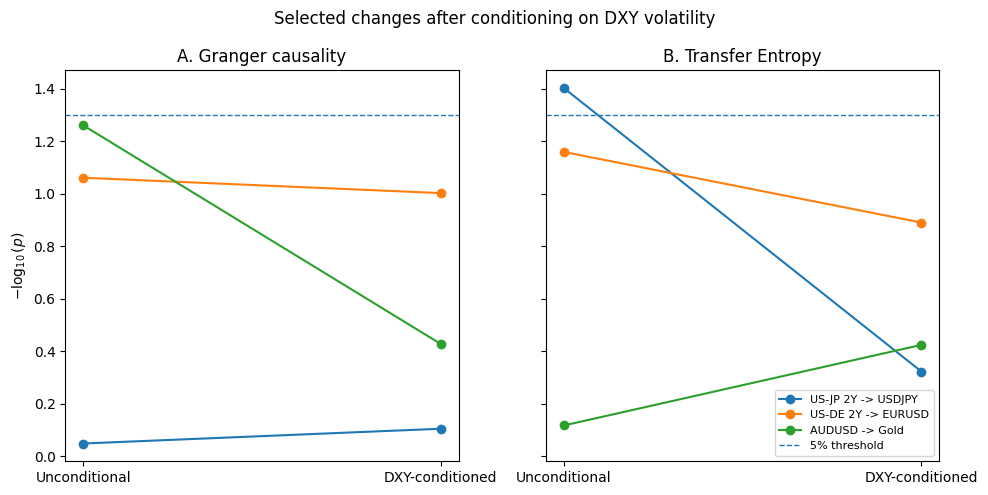

Saved: ../figures/focused_common_factor_attenuation.png
Saved: ../figures/focused_common_factor_attenuation.pdf


In [73]:
# ============================================================
# Plot focused attenuation
# ============================================================

FOCUS_ATTENUATION_PNG = (
    FIGURE_DIR
    / "focused_common_factor_attenuation.png"
)

FOCUS_ATTENUATION_PDF = (
    FIGURE_DIR
    / "focused_common_factor_attenuation.pdf"
)

threshold = -np.log10(ALPHA)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(10, 5),
    sharey=True,
)

for _, row in focus_attenuation_df.iterrows():

    axes[0].plot(
        [0, 1],
        [
            row["GC unconditional"],
            row["GC conditional"],
        ],
        marker="o",
        label=row["Label"],
    )

    axes[1].plot(
        [0, 1],
        [
            row["TE unconditional"],
            row["TE conditional"],
        ],
        marker="o",
        label=row["Label"],
    )

for ax in axes:

    ax.axhline(
        threshold,
        linestyle="--",
        linewidth=1,
        label="5% threshold",
    )

    ax.set_xticks(
        [0, 1]
    )

    ax.set_xticklabels(
        [
            "Unconditional",
            "DXY-conditioned",
        ]
    )

axes[0].set_ylabel(
    r"$-\log_{10}(p)$"
)

axes[0].set_title(
    "A. Granger causality"
)

axes[1].set_title(
    "B. Transfer Entropy"
)

axes[1].legend(
    fontsize=8
)

fig.suptitle(
    "Selected changes after conditioning on DXY volatility"
)

fig.tight_layout()

fig.savefig(
    FOCUS_ATTENUATION_PNG,
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    FOCUS_ATTENUATION_PDF,
    bbox_inches="tight",
)

plt.show()

print(
    f"Saved: {FOCUS_ATTENUATION_PNG}"
)

print(
    f"Saved: {FOCUS_ATTENUATION_PDF}"
)

### Interpretation: DXY conditioning and the common-factor experiment

The DXY control is used to test whether the bivariate relationships remain after accounting for a broad dollar-volatility factor. The interpretation follows the DGP4a/4b common-driver experiments in the synthetic analysis.

For US–Japan 2Y → USDJPY, unconditional TE is significant (p = 0.0396), but the relationship disappears after conditioning on DXY volatility (p = 0.4752). The maximum TE also falls from 0.0179 to 0.0068. This attenuation is consistent with the possibility that part of the bivariate information transfer was associated with a shared dollar-volatility factor. It does not establish DXY as the structural common cause.

The other channels are not significant under the baseline conditional TE specification. Conditional GC also detects no significant relationship in either direction for any of the four channels. Therefore, there is no baseline full-sample evidence that a source-market volatility shock retains statistically significant incremental predictive information after controlling for DXY volatility.

More generally, DXY conditioning changes GC and TE evidence differently across several directions. This may indicate that the DXY control absorbs shared or nonlinear volatility information while also changing the remaining linear predictive relationship. This pattern is treated as a secondary empirical finding rather than evidence of a specific economic mechanism.

Following DGP4a/4b, disappearance after conditioning is interpreted as consistent with common-factor attenuation. Persistence would indicate incremental information beyond the observed DXY control, but would still not establish structural causality.

## FOMC Event-State Analysis

FOMC event windows are defined on the original trading calendar as

\[
\{T_j-1,\;T_j,\;T_j+1\},
\]

where \(T_j\) is an FOMC announcement date and adjacent observations refer to
the preceding and following trading days.

Lagged source and target variables are constructed on each channel's full
chronological sample before observations are classified by event state.
An observation is classified as an event observation only according to whether
the target date \(t\) lies inside an FOMC window. This prevents lag construction
from treating non-consecutive event observations as consecutive trading days.

In [85]:
# ============================================================
# Load central-bank meeting calendar
# ============================================================

CB_CALENDAR_FILE = Path(
    "../data/cb_meeting_calendar.xlsx"
)

cb_calendar = pd.read_excel(
    CB_CALENDAR_FILE,
    sheet_name="CB_Meeting_Calendar",
)

cb_calendar["Date"] = pd.to_datetime(
    cb_calendar["Date"]
)

cb_calendar = (
    cb_calendar
    .sort_values("Date")
    .set_index("Date")
)

display(cb_calendar.head())

print(
    "Calendar range:",
    cb_calendar.index.min().date(),
    "to",
    cb_calendar.index.max().date()
)

print(
    "Number of FOMC dates:",
    int(cb_calendar["FOMC"].sum())
)

,FOMC,ECB,BOJ
Date,,,
2015-01-01,0,0,0
2015-01-02,0,0,0
2015-01-03,0,0,0
2015-01-04,0,0,0
2015-01-05,0,0,0


Calendar range: 2015-01-01 to 2024-12-31
Number of FOMC dates: 81


In [86]:
# ============================================================
# Extract FOMC announcement dates
# ============================================================

fomc_dates = pd.DatetimeIndex(
    cb_calendar.index[
        cb_calendar["FOMC"] == 1
    ]
).sort_values()

print(
    f"FOMC announcement dates: {len(fomc_dates)}"
)

display(
    pd.DataFrame({
        "FOMC date": fomc_dates
    }).head(10)
)

FOMC announcement dates: 81


,FOMC date
0,2015-01-28
1,2015-03-18
2,2015-04-29
3,2015-06-17
4,2015-07-29
5,2015-09-17
6,2015-10-28
7,2015-12-16
8,2016-01-27
9,2016-03-16


In [87]:
# ============================================================
# Construct FOMC windows on a trading calendar
# ============================================================

def construct_fomc_trading_windows(
    trading_index,
    fomc_dates,
):
    """
    Construct {T_j-1, T_j, T_j+1} on the supplied trading calendar.

    If an FOMC calendar date is not itself present in the trading index,
    the function reports it rather than silently remapping it.
    """

    trading_index = pd.DatetimeIndex(
        trading_index
    ).sort_values().unique()

    event_dates = set()
    window_records = []
    unmatched_dates = []

    for fomc_date in pd.DatetimeIndex(fomc_dates):

        if fomc_date not in trading_index:
            unmatched_dates.append(fomc_date)
            continue

        pos = trading_index.get_loc(
            fomc_date
        )

        if not isinstance(pos, (int, np.integer)):
            raise ValueError(
                f"Non-unique trading date: {fomc_date}"
            )

        previous_day = (
            trading_index[pos - 1]
            if pos > 0
            else pd.NaT
        )

        next_day = (
            trading_index[pos + 1]
            if pos < len(trading_index) - 1
            else pd.NaT
        )

        window = [
            previous_day,
            fomc_date,
            next_day,
        ]

        for date in window:
            if pd.notna(date):
                event_dates.add(date)

        window_records.append({
            "FOMC date": fomc_date,
            "T-1": previous_day,
            "T": fomc_date,
            "T+1": next_day,
        })

    return (
        pd.DatetimeIndex(
            sorted(event_dates)
        ),
        pd.DataFrame(window_records),
        pd.DatetimeIndex(unmatched_dates),
    )

In [88]:
# ============================================================
# FOMC trading-day windows by channel
# ============================================================

fomc_windows_by_channel = {}
fomc_window_audit_rows = []

for channel_name, samples in channel_data.items():

    # Event GC is bivariate, so use the channel's
    # natural bivariate chronological sample.
    data = samples["bivariate"].sort_index()

    (
        event_dates,
        window_table,
        unmatched_dates,
    ) = construct_fomc_trading_windows(
        trading_index=data.index,
        fomc_dates=fomc_dates,
    )

    fomc_windows_by_channel[channel_name] = {
        "event_dates": event_dates,
        "window_table": window_table,
        "unmatched_dates": unmatched_dates,
    }

    fomc_window_audit_rows.append({
        "Channel": channel_name,
        "Trading N": len(data),
        "Matched FOMC dates": len(window_table),
        "Unmatched FOMC dates": len(unmatched_dates),
        "Unique event trading days": len(event_dates),
    })

fomc_window_audit_df = pd.DataFrame(
    fomc_window_audit_rows
)

fomc_window_audit_df

,Channel,Trading N,Matched FOMC dates,Unmatched FOMC dates,Unique event trading days
0,US-DE 2Y -> EURUSD,2168,74,7,222
1,US-JP 2Y -> USDJPY,2009,59,22,177
2,Gold -> AUDUSD,2581,80,1,240
3,Brent -> USDCAD,2567,80,1,240


In [89]:
# ============================================================
# Audit unmatched FOMC dates
# ============================================================

for channel_name, info in (
    fomc_windows_by_channel.items()
):

    unmatched = info["unmatched_dates"]

    print("=" * 70)
    print(channel_name)

    if len(unmatched) == 0:
        print("All FOMC dates matched.")
    else:
        print(
            f"{len(unmatched)} unmatched FOMC dates:"
        )
        print(
            unmatched.strftime("%Y-%m-%d").tolist()
        )

US-DE 2Y -> EURUSD
7 unmatched FOMC dates:
['2017-05-03', '2017-11-01', '2018-05-02', '2019-05-01', '2020-03-15', '2023-05-03', '2024-05-01']
US-JP 2Y -> USDJPY
22 unmatched FOMC dates:
['2015-04-29', '2016-09-21', '2017-05-03', '2017-09-20', '2018-03-21', '2018-05-02', '2018-09-26', '2019-05-01', '2019-09-18', '2020-03-15', '2020-04-29', '2020-11-05', '2021-09-22', '2021-11-03', '2022-05-04', '2022-09-21', '2023-03-22', '2023-05-03', '2023-09-20', '2024-03-20', '2024-05-01', '2024-09-18']
Gold -> AUDUSD
1 unmatched FOMC dates:
['2020-03-15']
Brent -> USDCAD
1 unmatched FOMC dates:
['2020-03-15']


In [90]:
# ============================================================
# Build full-series GC design with event-state labels
# ============================================================

def build_event_gc_design(
    x,
    y,
    index,
    event_dates,
    p,
):
    """
    Construct all GC lags on the full chronological series first,
    then classify each target date Y_t as FOMC event/non-event.
    """

    df_event = pd.DataFrame(
        {
            "Y": np.asarray(y, dtype=float),
            "X": np.asarray(x, dtype=float),
        },
        index=pd.DatetimeIndex(index),
    ).sort_index()

    # Construct lags BEFORE event filtering
    for lag in range(1, p + 1):

        df_event[f"Y_lag{lag}"] = (
            df_event["Y"].shift(lag)
        )

        df_event[f"X_lag{lag}"] = (
            df_event["X"].shift(lag)
        )

    # Target-date event classification
    df_event["FOMC_event"] = (
        df_event.index.isin(event_dates)
    )

    # Only now remove rows unavailable because of lag construction
    required_cols = (
        ["Y"]
        + [
            f"Y_lag{i}"
            for i in range(1, p + 1)
        ]
        + [
            f"X_lag{i}"
            for i in range(1, p + 1)
        ]
    )

    df_event = df_event.dropna(
        subset=required_cols
    )

    return df_event

In [91]:
# ============================================================
# Audit lag construction around FOMC windows
# ============================================================

audit_channel = list(CHANNELS.keys())[0]

audit_data = (
    channel_data[audit_channel]["bivariate"]
    .sort_index()
)

audit_event_dates = (
    fomc_windows_by_channel[
        audit_channel
    ]["event_dates"]
)

audit_design = build_event_gc_design(
    x=audit_data["X"].to_numpy(),
    y=audit_data["Y"].to_numpy(),
    index=audit_data.index,
    event_dates=audit_event_dates,
    p=1,
)

display(
    audit_design.loc[
        audit_design["FOMC_event"]
    ].head(12)
)

,Y,X,Y_lag1,X_lag1,FOMC_event
Date,,,,,
2015-01-27,-0.0168,-0.0334,0.0376,-0.0078,True
2015-01-28,0.0243,-0.0332,-0.0168,-0.0334,True
2015-01-29,-0.0015,-0.0050,0.0243,-0.0332,True
2015-03-17,-0.0066,-0.0150,0.0279,-0.0307,True
2015-03-18,-0.0173,-0.0274,-0.0066,-0.0150,True
2015-03-19,0.1331,0.1667,-0.0173,-0.0274,True
2015-04-28,-0.0185,-0.0163,-0.0132,0.0020,True
2015-04-29,0.0018,0.0606,-0.0185,-0.0163,True
2015-04-30,0.0336,0.0350,0.0018,0.0606,True


In [92]:
# ============================================================
# Event-state sample-size audit
# ============================================================

event_sample_rows = []

for channel_name, samples in channel_data.items():

    data = samples["bivariate"].sort_index()

    event_dates = (
        fomc_windows_by_channel[
            channel_name
        ]["event_dates"]
    )

    # Use maximum p only for this integrity check.
    # Final GC will re-select p by AIC within each state.
    design = build_event_gc_design(
        x=data["X"].to_numpy(),
        y=data["Y"].to_numpy(),
        index=data.index,
        event_dates=event_dates,
        p=GC_MAX_LAG,
    )

    n_event = int(
        design["FOMC_event"].sum()
    )

    n_non_event = int(
        (~design["FOMC_event"]).sum()
    )

    event_sample_rows.append({
        "Channel": channel_name,
        "Event target N": n_event,
        "Non-event target N": n_non_event,
        "Event share": (
            n_event / len(design)
        ),
    })

event_sample_audit_df = pd.DataFrame(
    event_sample_rows
)

event_sample_audit_df

,Channel,Event target N,Non-event target N,Event share
0,US-DE 2Y -> EURUSD,222,1941,0.1026
1,US-JP 2Y -> USDJPY,177,1827,0.0883
2,Gold -> AUDUSD,240,2336,0.0932
3,Brent -> USDCAD,240,2322,0.0937


### Event and non-event Granger causality

GC is estimated separately for FOMC-window and non-event target observations.

For every channel, direction and state, the lag order is re-selected by AIC over
\(p=1,\ldots,5\). Lagged variables are always constructed on the full
chronological trading series before the target observations are divided into
event and non-event states.

The final GC decision is based on the joint F-test of all lagged source
coefficients. Differences in significance across states are treated as
descriptive evidence of state dependence rather than as a formal test of the
difference between states.

In [93]:
# ============================================================
# Event-state GC helper: fit one lag order
# ============================================================

def fit_event_state_gc(
    x,
    y,
    index,
    event_dates,
    p,
    state,
):
    """
    Fit one GC target equation for either the FOMC-event
    or non-event target observations.

    Lags are constructed on the full chronological series first.
    """

    design = build_event_gc_design(
        x=x,
        y=y,
        index=index,
        event_dates=event_dates,
        p=p,
    )

    if state == "Event":
        state_data = design[
            design["FOMC_event"]
        ].copy()

    elif state == "Non-event":
        state_data = design[
            ~design["FOMC_event"]
        ].copy()

    else:
        raise ValueError(
            "state must be 'Event' or 'Non-event'."
        )

    y_reg = state_data["Y"]

    regressors = (
        [f"Y_lag{i}" for i in range(1, p + 1)]
        +
        [f"X_lag{i}" for i in range(1, p + 1)]
    )

    X_reg = sm.add_constant(
        state_data[regressors],
        has_constant="add",
    )

    model = sm.OLS(
        y_reg,
        X_reg,
    ).fit()

    return {
        "model": model,
        "data": state_data,
        "N": len(state_data),
        "p": p,
    }

In [94]:
# ============================================================
# Event-state GC helper: select lag by AIC
# ============================================================

def select_event_state_gc_lag_aic(
    x,
    y,
    index,
    event_dates,
    state,
    max_lag=GC_MAX_LAG,
):
    """
    Select p = 1,...,max_lag by AIC separately
    within one event state.
    """

    rows = []

    for p in range(1, max_lag + 1):

        fit = fit_event_state_gc(
            x=x,
            y=y,
            index=index,
            event_dates=event_dates,
            p=p,
            state=state,
        )

        rows.append({
            "order": p,
            "N": fit["N"],
            "aic": fit["model"].aic,
        })

    aic_table = pd.DataFrame(rows)

    best_order = int(
        aic_table.loc[
            aic_table["aic"].idxmin(),
            "order"
        ]
    )

    return best_order, aic_table

In [95]:
# ============================================================
# Run one GC direction within one event state
# ============================================================

def run_event_state_gc_direction(
    x,
    y,
    index,
    event_dates,
    direction,
    state,
    max_lag=GC_MAX_LAG,
    alpha=ALPHA,
):
    """
    Run linear GC for one direction and one state.

    1. Select p by AIC within the state.
    2. Fit the selected model.
    3. Jointly test all lagged source coefficients.
    """

    selected_p, aic_table = (
        select_event_state_gc_lag_aic(
            x=x,
            y=y,
            index=index,
            event_dates=event_dates,
            state=state,
            max_lag=max_lag,
        )
    )

    fit = fit_event_state_gc(
        x=x,
        y=y,
        index=index,
        event_dates=event_dates,
        p=selected_p,
        state=state,
    )

    model = fit["model"]

    x_lag_names = [
        f"X_lag{i}"
        for i in range(1, selected_p + 1)
    ]

    param_names = list(
        model.params.index
    )

    restriction = np.zeros(
        (
            selected_p,
            len(model.params)
        )
    )

    for row, name in enumerate(
        x_lag_names
    ):
        restriction[
            row,
            param_names.index(name)
        ] = 1.0

    f_test = model.f_test(
        restriction
    )

    f_stat = float(
        np.asarray(
            f_test.fvalue
        ).squeeze()
    )

    global_pvalue = float(
        np.asarray(
            f_test.pvalue
        ).squeeze()
    )

    # Descriptive best source lag
    source_lag_pvalues = {
        lag: float(
            model.pvalues[
                f"X_lag{lag}"
            ]
        )
        for lag in range(
            1,
            selected_p + 1
        )
    }

    best_source_lag = min(
        source_lag_pvalues,
        key=source_lag_pvalues.get
    )

    return {
        "direction": direction,
        "state": state,
        "N": fit["N"],
        "selected_p": selected_p,
        "F_stat": f_stat,
        "global_pvalue": global_pvalue,
        "significant": (
            global_pvalue < alpha
        ),
        "best_source_lag": best_source_lag,
        "best_lag_pvalue": (
            source_lag_pvalues[
                best_source_lag
            ]
        ),
        "source_lag_pvalues": source_lag_pvalues,
        "aic_table": aic_table,
    }

In [96]:
# ============================================================
# Event / non-event GC:
# all channels, directions and states
# ============================================================

event_gc_results = []
event_gc_details = {}

STATES = [
    "Event",
    "Non-event",
]

for channel_name, samples in channel_data.items():

    data = (
        samples["bivariate"]
        .sort_index()
    )

    event_dates = (
        fomc_windows_by_channel[
            channel_name
        ]["event_dates"]
    )

    x = data["X"].to_numpy()
    y = data["Y"].to_numpy()
    index = data.index

    print("=" * 70)
    print(channel_name)

    event_gc_details[
        channel_name
    ] = {}

    for direction in DIRECTIONS:

        if direction == "X->Y":
            source = x
            target = y

        else:
            source = y
            target = x

        event_gc_details[
            channel_name
        ][direction] = {}

        for state in STATES:

            print(
                f"Running {direction}, {state} ..."
            )

            result = (
                run_event_state_gc_direction(
                    x=source,
                    y=target,
                    index=index,
                    event_dates=event_dates,
                    direction=direction,
                    state=state,
                )
            )

            event_gc_details[
                channel_name
            ][direction][state] = result

            event_gc_results.append({
                "Channel": channel_name,
                "Direction": direction,
                "State": state,
                "N": result["N"],
                "Selected p": result["selected_p"],
                "F statistic": result["F_stat"],
                "Global p-value": result["global_pvalue"],
                "Significant": result["significant"],
                "Best source lag": result["best_source_lag"],
                "Best lag p-value": result["best_lag_pvalue"],
            })

    print("Done.\n")

US-DE 2Y -> EURUSD
Running X->Y, Event ...
Running X->Y, Non-event ...
Running Y->X, Event ...
Running Y->X, Non-event ...
Done.

US-JP 2Y -> USDJPY
Running X->Y, Event ...
Running X->Y, Non-event ...
Running Y->X, Event ...
Running Y->X, Non-event ...
Done.

Gold -> AUDUSD
Running X->Y, Event ...
Running X->Y, Non-event ...
Running Y->X, Event ...
Running Y->X, Non-event ...
Done.

Brent -> USDCAD
Running X->Y, Event ...
Running X->Y, Non-event ...
Running Y->X, Event ...
Running Y->X, Non-event ...
Done.



In [97]:
# ============================================================
# Event-state GC summary
# ============================================================

event_gc_df = pd.DataFrame(
    event_gc_results
)

event_gc_df

,Channel,Direction,State,N,Selected p,F statistic,Global p-value,Significant,Best source lag,Best lag p-value
0,US-DE 2Y -> EURUSD,X->Y,Event,222,1,0.1241,0.7249,False,1,0.7249
1,US-DE 2Y -> EURUSD,X->Y,Non-event,1945,1,2.8835,0.0897,False,1,0.0897
2,US-DE 2Y -> EURUSD,Y->X,Event,222,2,4.0311,0.0191,True,2,0.0147
3,US-DE 2Y -> EURUSD,Y->X,Non-event,1945,1,0.1553,0.6935,False,1,0.6935
4,US-JP 2Y -> USDJPY,X->Y,Event,177,4,1.8606,0.1197,False,3,0.0441
5,US-JP 2Y -> USDJPY,X->Y,Non-event,1831,1,0.0553,0.8141,False,1,0.8141
6,US-JP 2Y -> USDJPY,Y->X,Event,177,1,0.1173,0.7324,False,1,0.7324
7,US-JP 2Y -> USDJPY,Y->X,Non-event,1830,2,1.0257,0.3588,False,1,0.3023
8,Gold -> AUDUSD,X->Y,Event,240,1,0.6333,0.4269,False,1,0.4269
9,Gold -> AUDUSD,X->Y,Non-event,2340,1,0.1809,0.6706,False,1,0.6706


In [98]:
# ============================================================
# Event-state GC sanity checks
# ============================================================

assert len(
    event_gc_df
) == (
    len(CHANNELS)
    * len(DIRECTIONS)
    * len(STATES)
)

assert event_gc_df[
    "Selected p"
].between(
    1,
    GC_MAX_LAG
).all()

assert event_gc_df[
    "Global p-value"
].between(
    0,
    1
).all()

assert event_gc_df[
    "Best source lag"
].ge(1).all()

assert (
    event_gc_df[
        "Best source lag"
    ]
    <=
    event_gc_df[
        "Selected p"
    ]
).all()

print(
    "Event-state GC checks passed."
)

Event-state GC checks passed.


In [99]:
# ============================================================
# Event vs non-event GC comparison
# ============================================================

event_gc_comparison = (
    event_gc_df
    .pivot(
        index=[
            "Channel",
            "Direction",
        ],
        columns="State",
        values=[
            "N",
            "Selected p",
            "Global p-value",
            "Significant",
        ],
    )
)

event_gc_comparison.columns = [
    f"{metric} | {state}"
    for metric, state
    in event_gc_comparison.columns
]

event_gc_comparison = (
    event_gc_comparison
    .reset_index()
)

event_gc_comparison

,Channel,Direction,N | Event,N | Non-event,Selected p | Event,Selected p | Non-event,Global p-value | Event,Global p-value | Non-event,Significant | Event,Significant | Non-event
0,Brent -> USDCAD,X->Y,240,2326,1,1,0.5200,0.2215,False,False
1,Brent -> USDCAD,Y->X,240,2326,1,1,0.0195,0.4599,True,False
2,Gold -> AUDUSD,X->Y,240,2340,1,1,0.4269,0.6706,False,False
3,Gold -> AUDUSD,Y->X,240,2340,2,1,0.1268,0.0759,False,False
4,US-DE 2Y -> EURUSD,X->Y,222,1945,1,1,0.7249,0.0897,False,False
5,US-DE 2Y -> EURUSD,Y->X,222,1945,2,1,0.0191,0.6935,True,False
6,US-JP 2Y -> USDJPY,X->Y,177,1831,4,1,0.1197,0.8141,False,False
7,US-JP 2Y -> USDJPY,Y->X,177,1830,1,2,0.7324,0.3588,False,False


In [100]:
# ============================================================
# Descriptive event-state detection pattern
# ============================================================

def classify_event_gc(row):

    event_sig = bool(
        row["Significant | Event"]
    )

    non_event_sig = bool(
        row["Significant | Non-event"]
    )

    if event_sig and non_event_sig:
        return "Detected in both"

    if event_sig and not non_event_sig:
        return "Event only"

    if not event_sig and non_event_sig:
        return "Non-event only"

    return "Undetected in both"


event_gc_comparison[
    "Detection pattern"
] = (
    event_gc_comparison.apply(
        classify_event_gc,
        axis=1,
    )
)

event_gc_comparison

,Channel,Direction,N | Event,N | Non-event,Selected p | Event,Selected p | Non-event,Global p-value | Event,Global p-value | Non-event,Significant | Event,Significant | Non-event,Detection pattern
0,Brent -> USDCAD,X->Y,240,2326,1,1,0.5200,0.2215,False,False,Undetected in both
1,Brent -> USDCAD,Y->X,240,2326,1,1,0.0195,0.4599,True,False,Event only
2,Gold -> AUDUSD,X->Y,240,2340,1,1,0.4269,0.6706,False,False,Undetected in both
3,Gold -> AUDUSD,Y->X,240,2340,2,1,0.1268,0.0759,False,False,Undetected in both
4,US-DE 2Y -> EURUSD,X->Y,222,1945,1,1,0.7249,0.0897,False,False,Undetected in both
5,US-DE 2Y -> EURUSD,Y->X,222,1945,2,1,0.0191,0.6935,True,False,Event only
6,US-JP 2Y -> USDJPY,X->Y,177,1831,4,1,0.1197,0.8141,False,False,Undetected in both
7,US-JP 2Y -> USDJPY,Y->X,177,1830,1,2,0.7324,0.3588,False,False,Undetected in both


In [101]:
# ============================================================
# Save event-state GC results
# ============================================================

EVENT_GC_FILE = (
    TABLE_DIR
    / "fomc_event_non_event_gc.csv"
)

event_gc_df.to_csv(
    EVENT_GC_FILE,
    index=False,
)

EVENT_GC_COMPARISON_FILE = (
    TABLE_DIR
    / "fomc_event_non_event_gc_comparison.csv"
)

event_gc_comparison.to_csv(
    EVENT_GC_COMPARISON_FILE,
    index=False,
)

print(
    f"Saved: {EVENT_GC_FILE}"
)

print(
    f"Saved: {EVENT_GC_COMPARISON_FILE}"
)

Saved: ../tables/fomc_event_non_event_gc.csv
Saved: ../tables/fomc_event_non_event_gc_comparison.csv


### Event and non-event Transfer Entropy

Transfer Entropy is estimated separately for FOMC-window and non-event target
observations using the pre-specified baseline embedding \(m=1\), \(k=10\), and
source lags \(\ell=1,\ldots,5\).

All lagged variables are constructed on the full chronological trading series
before observations are classified according to whether the target date
\(Y_t\) falls inside an FOMC window. This preserves the actual trading-day
temporal structure and prevents non-consecutive event observations from being
treated as consecutive observations.

Inference follows the same maximum-statistic circular-shift surrogate procedure
used in the full-sample analysis. For each state, the observed statistic is the
maximum estimated TE across source lags 1--5. The global p-value therefore
accounts for searching across the five pre-specified source lags.

Because the FOMC-window samples are substantially smaller than the non-event
samples, differences in statistical significance across states are interpreted
as descriptive evidence of state dependence rather than as a formal test that
the underlying dependence differs between states.

In [104]:
# ============================================================
# Build full-series TE inputs before event-state classification
# ============================================================

def build_event_te_design(
    x,
    y,
    index,
    event_dates,
    lag,
    m=1,
):
    """
    Construct TE inputs on the full chronological series first,
    then classify observations according to whether target date Y_t
    belongs to the FOMC event window.

    Baseline:
        TE_{X->Y}(lag)
        = I(Y_t ; X_{t-lag} | Y_{t-1})
    """

    if m != 1:
        raise ValueError(
            "This event-state baseline is pre-specified with m=1."
        )

    df_event_te = pd.DataFrame(
        {
            "Y": np.asarray(y, dtype=float),
            "X": np.asarray(x, dtype=float),
        },
        index=pd.DatetimeIndex(index),
    ).sort_index()

    # Construct lags on the full chronological series
    df_event_te["Y_lag1"] = (
        df_event_te["Y"].shift(1)
    )

    df_event_te[f"X_lag{lag}"] = (
        df_event_te["X"].shift(lag)
    )

    # Classify according to the TARGET date t
    df_event_te["FOMC_event"] = (
        df_event_te.index.isin(event_dates)
    )

    # Drop only after lag construction
    df_event_te = df_event_te.dropna(
        subset=[
            "Y",
            "Y_lag1",
            f"X_lag{lag}",
        ]
    )

    return df_event_te

In [106]:
# ============================================================
# Event-state TE dependency check
# ============================================================

required_objects = [
    "TE_M",
    "TE_K",
    "TE_LAGS",
    "TE_SURROGATES",
    "ALPHA",
    "CHANNELS",
    "DIRECTIONS",
    "STATES",
    "channel_data",
    "fomc_windows_by_channel",
    "TABLE_DIR",
    "ksg_cmi",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise NameError(
        f"Missing required objects: {missing_objects}"
    )

print("Event-state TE dependencies available.")
print(
    f"m={TE_M}, "
    f"k={TE_K}, "
    f"lags={TE_LAGS}, "
    f"B={TE_SURROGATES}"
)

Event-state TE dependencies available.
m=1, k=10, lags=[1, 2, 3, 4, 5], B=100


In [107]:
# ============================================================
# Build full-series TE inputs before event-state filtering
# ============================================================

def build_event_te_design(
    x,
    y,
    index,
    event_dates,
    lag,
    m=TE_M,
):
    """
    Construct TE inputs on the full chronological series first.

    Baseline:
        TE_{X->Y}(lag)
        = I(Y_t ; X_{t-lag} | Y_{t-1})

    Event classification is applied only to the target date t.
    """

    if m != 1:
        raise ValueError(
            "Baseline event-state TE is pre-specified with m=1."
        )

    df_te = pd.DataFrame(
        {
            "Y": np.asarray(y, dtype=float),
            "X": np.asarray(x, dtype=float),
        },
        index=pd.DatetimeIndex(index),
    ).sort_index()

    # Construct temporal variables BEFORE filtering by event state
    df_te["Y_lag1"] = (
        df_te["Y"].shift(1)
    )

    df_te[f"X_lag{lag}"] = (
        df_te["X"].shift(lag)
    )

    # Classify by target date t
    df_te["FOMC_event"] = (
        df_te.index.isin(event_dates)
    )

    # Remove rows only after lag construction
    df_te = df_te.dropna(
        subset=[
            "Y",
            "Y_lag1",
            f"X_lag{lag}",
        ]
    )

    return df_te

In [108]:
# ============================================================
# Event-state TE sample-size audit
# ============================================================

event_te_sample_rows = []

for channel_name, samples in channel_data.items():

    data = (
        samples["bivariate"]
        .sort_index()
    )

    event_dates = (
        fomc_windows_by_channel[
            channel_name
        ]["event_dates"]
    )

    for lag in TE_LAGS:

        design = build_event_te_design(
            x=data["X"].to_numpy(),
            y=data["Y"].to_numpy(),
            index=data.index,
            event_dates=event_dates,
            lag=lag,
            m=TE_M,
        )

        event_te_sample_rows.append({
            "Channel": channel_name,
            "Lag": lag,
            "Event N": int(
                design["FOMC_event"].sum()
            ),
            "Non-event N": int(
                (~design["FOMC_event"]).sum()
            ),
        })

event_te_sample_audit_df = pd.DataFrame(
    event_te_sample_rows
)

event_te_sample_audit_df

,Channel,Lag,Event N,Non-event N
0,US-DE 2Y -> EURUSD,1,222,1945
1,US-DE 2Y -> EURUSD,2,222,1944
2,US-DE 2Y -> EURUSD,3,222,1943
3,US-DE 2Y -> EURUSD,4,222,1942
4,US-DE 2Y -> EURUSD,5,222,1941
5,US-JP 2Y -> USDJPY,1,177,1831
6,US-JP 2Y -> USDJPY,2,177,1830
7,US-JP 2Y -> USDJPY,3,177,1829
8,US-JP 2Y -> USDJPY,4,177,1828
9,US-JP 2Y -> USDJPY,5,177,1827


In [109]:
# ============================================================
# TE at one source lag within one event state
# ============================================================

def estimate_event_state_te_lag(
    x,
    y,
    index,
    event_dates,
    lag,
    state,
    k=TE_K,
):
    """
    Estimate:
        I(Y_t ; X_{t-lag} | Y_{t-1})

    within Event or Non-event target observations.
    """

    design = build_event_te_design(
        x=x,
        y=y,
        index=index,
        event_dates=event_dates,
        lag=lag,
        m=TE_M,
    )

    if state == "Event":
        state_df = design[
            design["FOMC_event"]
        ].copy()

    elif state == "Non-event":
        state_df = design[
            ~design["FOMC_event"]
        ].copy()

    else:
        raise ValueError(
            "state must be 'Event' or 'Non-event'."
        )

    y_t = (
        state_df["Y"]
        .to_numpy()
        .reshape(-1, 1)
    )

    x_lag = (
        state_df[f"X_lag{lag}"]
        .to_numpy()
        .reshape(-1, 1)
    )

    y_history = (
        state_df["Y_lag1"]
        .to_numpy()
        .reshape(-1, 1)
    )

    te_value = ksg_cmi(
        y_t=y_t,
        y_history=y_history,
        x_source=x_lag,
        k=k,
    )

    return float(te_value), len(state_df)

In [110]:
# ============================================================
# Observed event-state TE profile
# ============================================================

def event_state_te_profile(
    x,
    y,
    index,
    event_dates,
    state,
    k=TE_K,
    lags=TE_LAGS,
):
    """
    Estimate TE across all pre-specified source lags.
    """

    te_by_lag = {}
    n_by_lag = {}

    for lag in lags:

        te_value, n = (
            estimate_event_state_te_lag(
                x=x,
                y=y,
                index=index,
                event_dates=event_dates,
                lag=lag,
                state=state,
                k=k,
            )
        )

        te_by_lag[lag] = te_value
        n_by_lag[lag] = n

    peak_lag = max(
        te_by_lag,
        key=te_by_lag.get
    )

    max_te = te_by_lag[
        peak_lag
    ]

    return {
        "TE_by_lag": te_by_lag,
        "N_by_lag": n_by_lag,
        "peak_lag": int(peak_lag),
        "max_te": float(max_te),
    }

In [111]:
# ============================================================
# Run one event-state TE direction
# ============================================================

def run_event_state_te_direction(
    x,
    y,
    index,
    event_dates,
    direction,
    state,
    k=TE_K,
    lags=TE_LAGS,
    n_surrogates=TE_SURROGATES,
    alpha=ALPHA,
    seed=42000,
):
    """
    Event-state TE with maximum-statistic circular-shift inference.

    Circular shifts are applied to the FULL chronological source series.
    Event/non-event filtering is applied afterwards.
    """

    x = np.asarray(
        x,
        dtype=float
    )

    y = np.asarray(
        y,
        dtype=float
    )

    if len(x) != len(y):
        raise ValueError(
            "Source and target must have equal length."
        )

    rng = np.random.default_rng(
        seed
    )

    # --------------------------------------------------------
    # 1. Observed TE profile
    # --------------------------------------------------------

    observed = event_state_te_profile(
        x=x,
        y=y,
        index=index,
        event_dates=event_dates,
        state=state,
        k=k,
        lags=lags,
    )

    observed_max = observed[
        "max_te"
    ]

    # --------------------------------------------------------
    # 2. Circular-shift surrogate maximum distribution
    # --------------------------------------------------------

    n = len(x)

    surrogate_maxima = np.empty(
        n_surrogates
    )

    # Avoid trivially tiny shifts
    min_shift = max(lags) + 1

    allowed_shifts = np.arange(
        min_shift,
        n - min_shift
    )

    if len(allowed_shifts) == 0:
        raise ValueError(
            "Series too short for surrogate shifting."
        )

    for b in range(
        n_surrogates
    ):

        shift = int(
            rng.choice(
                allowed_shifts
            )
        )

        x_shifted = np.roll(
            x,
            shift
        )

        surrogate_profile = (
            event_state_te_profile(
                x=x_shifted,
                y=y,
                index=index,
                event_dates=event_dates,
                state=state,
                k=k,
                lags=lags,
            )
        )

        surrogate_maxima[b] = (
            surrogate_profile[
                "max_te"
            ]
        )

    # --------------------------------------------------------
    # 3. Maximum-statistic global p-value
    # --------------------------------------------------------

    global_pvalue = (
        1
        + np.sum(
            surrogate_maxima
            >= observed_max
        )
    ) / (
        n_surrogates + 1
    )

    return {
        "direction": direction,
        "state": state,

        "N": int(
            min(
                observed[
                    "N_by_lag"
                ].values()
            )
        ),

        "TE_by_lag": (
            observed[
                "TE_by_lag"
            ]
        ),

        "max_TE": float(
            observed_max
        ),

        "peak_lag": int(
            observed[
                "peak_lag"
            ]
        ),

        "global_pvalue": float(
            global_pvalue
        ),

        "significant": bool(
            global_pvalue < alpha
        ),

        "surrogate_maxima": (
            surrogate_maxima
        ),
    }

In [112]:
# ============================================================
# Run event / non-event TE:
# all channels, both directions, both states
# ============================================================

event_te_results = []
event_te_details = {}

seed_counter = 42000

for channel_name, samples in channel_data.items():

    data = (
        samples["bivariate"]
        .sort_index()
    )

    event_dates = (
        fomc_windows_by_channel[
            channel_name
        ]["event_dates"]
    )

    x = data["X"].to_numpy()
    y = data["Y"].to_numpy()
    index = data.index

    print("=" * 70)
    print(channel_name)

    event_te_details[
        channel_name
    ] = {}

    for direction in DIRECTIONS:

        if direction == "X->Y":

            source = x
            target = y

        elif direction == "Y->X":

            source = y
            target = x

        else:

            raise ValueError(
                f"Unknown direction: {direction}"
            )

        event_te_details[
            channel_name
        ][direction] = {}

        for state in STATES:

            print(
                f"Running TE {direction}, {state} ..."
            )

            result = (
                run_event_state_te_direction(
                    x=source,
                    y=target,
                    index=index,
                    event_dates=event_dates,
                    direction=direction,
                    state=state,
                    k=TE_K,
                    lags=TE_LAGS,
                    n_surrogates=TE_SURROGATES,
                    alpha=ALPHA,
                    seed=seed_counter,
                )
            )

            seed_counter += 1

            event_te_details[
                channel_name
            ][direction][state] = (
                result
            )

            event_te_results.append({
                "Channel": channel_name,
                "Direction": direction,
                "State": state,
                "N": result["N"],
                "Max TE": result["max_TE"],
                "Peak lag": result["peak_lag"],
                "Global p-value": result["global_pvalue"],
                "Significant": result["significant"],
            })

    print("Done.\n")

print("Event-state TE complete.")

US-DE 2Y -> EURUSD
Running TE X->Y, Event ...
Running TE X->Y, Non-event ...
Running TE Y->X, Event ...
Running TE Y->X, Non-event ...
Done.

US-JP 2Y -> USDJPY
Running TE X->Y, Event ...
Running TE X->Y, Non-event ...
Running TE Y->X, Event ...
Running TE Y->X, Non-event ...
Done.

Gold -> AUDUSD
Running TE X->Y, Event ...
Running TE X->Y, Non-event ...
Running TE Y->X, Event ...
Running TE Y->X, Non-event ...
Done.

Brent -> USDCAD
Running TE X->Y, Event ...
Running TE X->Y, Non-event ...
Running TE Y->X, Event ...
Running TE Y->X, Non-event ...
Done.

Event-state TE complete.


In [113]:
# ============================================================
# Event-state TE summary
# ============================================================

event_te_df = pd.DataFrame(
    event_te_results
)

event_te_df

,Channel,Direction,State,N,Max TE,Peak lag,Global p-value,Significant
0,US-DE 2Y -> EURUSD,X->Y,Event,222,0.0309,4,0.1980,False
1,US-DE 2Y -> EURUSD,X->Y,Non-event,1941,0.0130,4,0.2871,False
2,US-DE 2Y -> EURUSD,Y->X,Event,222,0.0529,5,0.0099,True
3,US-DE 2Y -> EURUSD,Y->X,Non-event,1941,0.0161,3,0.0297,True
4,US-JP 2Y -> USDJPY,X->Y,Event,177,0.0138,3,0.6238,False
5,US-JP 2Y -> USDJPY,X->Y,Non-event,1827,0.0165,1,0.0990,False
6,US-JP 2Y -> USDJPY,Y->X,Event,177,0.0235,5,0.3069,False
7,US-JP 2Y -> USDJPY,Y->X,Non-event,1827,0.0163,4,0.1881,False
8,Gold -> AUDUSD,X->Y,Event,240,0.0314,2,0.1386,False
9,Gold -> AUDUSD,X->Y,Non-event,2336,0.0163,3,0.0495,True


In [114]:
# ============================================================
# Event-state TE sanity checks
# ============================================================

assert len(
    event_te_df
) == (
    len(CHANNELS)
    * len(DIRECTIONS)
    * len(STATES)
)

assert event_te_df[
    "Peak lag"
].isin(
    TE_LAGS
).all()

assert event_te_df[
    "Global p-value"
].between(
    0,
    1
).all()

assert (
    event_te_df["N"] > TE_K
).all()

print(
    "Event-state TE checks passed."
)

Event-state TE checks passed.


In [115]:
# ============================================================
# Event-state TE by source lag
# ============================================================

event_te_lag_rows = []

for channel_name, directions in (
    event_te_details.items()
):

    for direction, states in (
        directions.items()
    ):

        for state, result in (
            states.items()
        ):

            for lag, te_value in (
                result[
                    "TE_by_lag"
                ].items()
            ):

                event_te_lag_rows.append({
                    "Channel": channel_name,
                    "Direction": direction,
                    "State": state,
                    "Lag": lag,
                    "TE": te_value,
                    "Peak": (
                        lag
                        == result[
                            "peak_lag"
                        ]
                    ),
                })

event_te_by_lag_df = pd.DataFrame(
    event_te_lag_rows
)

event_te_by_lag_df

,Channel,Direction,State,Lag,TE,Peak
0,US-DE 2Y -> EURUSD,X->Y,Event,1,-0.0105,False
1,US-DE 2Y -> EURUSD,X->Y,Event,2,-0.0057,False
2,US-DE 2Y -> EURUSD,X->Y,Event,3,0.0056,False
3,US-DE 2Y -> EURUSD,X->Y,Event,4,0.0309,True
4,US-DE 2Y -> EURUSD,X->Y,Event,5,-0.0073,False
...,...,...,...,...,...,...
75,Brent -> USDCAD,Y->X,Non-event,1,0.0017,False
76,Brent -> USDCAD,Y->X,Non-event,2,0.0013,False
77,Brent -> USDCAD,Y->X,Non-event,3,-0.0016,False
78,Brent -> USDCAD,Y->X,Non-event,4,0.0068,True


In [116]:
# ============================================================
# Event vs non-event TE comparison
# ============================================================

event_te_comparison = (
    event_te_df
    .pivot(
        index=[
            "Channel",
            "Direction",
        ],
        columns="State",
        values=[
            "N",
            "Max TE",
            "Peak lag",
            "Global p-value",
            "Significant",
        ],
    )
)

event_te_comparison.columns = [
    f"{metric} | {state}"
    for metric, state
    in event_te_comparison.columns
]

event_te_comparison = (
    event_te_comparison
    .reset_index()
)


def classify_event_te(row):

    event_sig = bool(
        row[
            "Significant | Event"
        ]
    )

    non_event_sig = bool(
        row[
            "Significant | Non-event"
        ]
    )

    if event_sig and non_event_sig:
        return "Detected in both"

    if event_sig and not non_event_sig:
        return "Event only"

    if not event_sig and non_event_sig:
        return "Non-event only"

    return "Undetected in both"


event_te_comparison[
    "Detection pattern"
] = (
    event_te_comparison.apply(
        classify_event_te,
        axis=1
    )
)

event_te_comparison

,Channel,Direction,N | Event,N | Non-event,Max TE | Event,Max TE | Non-event,Peak lag | Event,Peak lag | Non-event,Global p-value | Event,Global p-value | Non-event,Significant | Event,Significant | Non-event,Detection pattern
0,Brent -> USDCAD,X->Y,240,2322,0.0186,0.0058,5,2,0.4752,0.6040,False,False,Undetected in both
1,Brent -> USDCAD,Y->X,240,2322,0.0135,0.0068,1,4,0.5050,0.4158,False,False,Undetected in both
2,Gold -> AUDUSD,X->Y,240,2336,0.0314,0.0163,2,3,0.1386,0.0495,False,True,Non-event only
3,Gold -> AUDUSD,Y->X,240,2336,0.0129,0.0058,1,1,0.6337,0.7426,False,False,Undetected in both
4,US-DE 2Y -> EURUSD,X->Y,222,1941,0.0309,0.0130,4,4,0.1980,0.2871,False,False,Undetected in both
5,US-DE 2Y -> EURUSD,Y->X,222,1941,0.0529,0.0161,5,3,0.0099,0.0297,True,True,Detected in both
6,US-JP 2Y -> USDJPY,X->Y,177,1827,0.0138,0.0165,3,1,0.6238,0.0990,False,False,Undetected in both
7,US-JP 2Y -> USDJPY,Y->X,177,1827,0.0235,0.0163,5,4,0.3069,0.1881,False,False,Undetected in both


In [117]:
# ============================================================
# Save event-state TE results
# ============================================================

EVENT_TE_FILE = (
    TABLE_DIR
    / "fomc_event_non_event_te.csv"
)

EVENT_TE_COMPARISON_FILE = (
    TABLE_DIR
    / "fomc_event_non_event_te_comparison.csv"
)

EVENT_TE_LAG_FILE = (
    TABLE_DIR
    / "fomc_event_non_event_te_by_lag.csv"
)

event_te_df.to_csv(
    EVENT_TE_FILE,
    index=False
)

event_te_comparison.to_csv(
    EVENT_TE_COMPARISON_FILE,
    index=False
)

event_te_by_lag_df.to_csv(
    EVENT_TE_LAG_FILE,
    index=False
)

print(
    f"Saved: {EVENT_TE_FILE}"
)

print(
    f"Saved: {EVENT_TE_COMPARISON_FILE}"
)

print(
    f"Saved: {EVENT_TE_LAG_FILE}"
)

Saved: ../tables/fomc_event_non_event_te.csv
Saved: ../tables/fomc_event_non_event_te_comparison.csv
Saved: ../tables/fomc_event_non_event_te_by_lag.csv


### Event-state TE audit

The event-state TE results are audited before substantive interpretation.

The audit compares full-sample, FOMC-event and non-event TE profiles using the
same source-target convention, estimator and source-lag set. It also compares
the observed maximum TE with the corresponding circular-shift surrogate
distribution.

No specification or inference rule is changed.

In [118]:
# ============================================================
# Audit 1: combine full / event / non-event TE summaries
# ============================================================

event_te_audit_rows = []

for channel_name in CHANNELS.keys():

    for direction in DIRECTIONS:

        # Full sample
        full_result = te_details[
            channel_name
        ][direction]

        event_te_audit_rows.append({
            "Channel": channel_name,
            "Direction": direction,
            "State": "Full",
            "N": int(
                channel_data[
                    channel_name
                ]["bivariate"].shape[0]
            ),
            "Max TE": full_result[
                "max_TE"
            ],
            "Peak lag": full_result[
                "peak_lag"
            ],
            "Global p-value": full_result[
                "global_pvalue"
            ],
        })

        # Event / non-event
        for state in STATES:

            result = event_te_details[
                channel_name
            ][direction][state]

            event_te_audit_rows.append({
                "Channel": channel_name,
                "Direction": direction,
                "State": state,
                "N": result["N"],
                "Max TE": result["max_TE"],
                "Peak lag": result["peak_lag"],
                "Global p-value": result[
                    "global_pvalue"
                ],
            })

event_te_audit_summary = pd.DataFrame(
    event_te_audit_rows
)

event_te_audit_summary

,Channel,Direction,State,N,Max TE,Peak lag,Global p-value
0,US-DE 2Y -> EURUSD,X->Y,Full,2168,0.0165,4,0.0693
1,US-DE 2Y -> EURUSD,X->Y,Event,222,0.0309,4,0.1980
2,US-DE 2Y -> EURUSD,X->Y,Non-event,1941,0.0130,4,0.2871
3,US-DE 2Y -> EURUSD,Y->X,Full,2168,0.0137,3,0.1287
4,US-DE 2Y -> EURUSD,Y->X,Event,222,0.0529,5,0.0099
5,US-DE 2Y -> EURUSD,Y->X,Non-event,1941,0.0161,3,0.0297
6,US-JP 2Y -> USDJPY,X->Y,Full,2009,0.0179,1,0.0396
7,US-JP 2Y -> USDJPY,X->Y,Event,177,0.0138,3,0.6238
8,US-JP 2Y -> USDJPY,X->Y,Non-event,1827,0.0165,1,0.0990
9,US-JP 2Y -> USDJPY,Y->X,Full,2009,0.0135,4,0.2475


In [119]:
# ============================================================
# Audit 2: focus cases
# ============================================================

FOCUS_EVENT_TE_CASES = [
    (
        "US-JP 2Y -> USDJPY",
        "X->Y",
        "US-JP 2Y -> USDJPY",
    ),
    (
        "US-DE 2Y -> EURUSD",
        "Y->X",
        "EURUSD -> US-DE 2Y",
    ),
    (
        "Gold -> AUDUSD",
        "X->Y",
        "Gold -> AUDUSD",
    ),
]

focus_event_te_rows = []

for channel, direction, label in FOCUS_EVENT_TE_CASES:

    temp = event_te_audit_summary[
        (
            event_te_audit_summary[
                "Channel"
            ] == channel
        )
        &
        (
            event_te_audit_summary[
                "Direction"
            ] == direction
        )
    ].copy()

    temp["Label"] = label

    focus_event_te_rows.append(
        temp
    )

focus_event_te_summary = pd.concat(
    focus_event_te_rows,
    ignore_index=True,
)

focus_event_te_summary[
    [
        "Label",
        "State",
        "N",
        "Max TE",
        "Peak lag",
        "Global p-value",
    ]
]

,Label,State,N,Max TE,Peak lag,Global p-value
0,US-JP 2Y -> USDJPY,Full,2009,0.0179,1,0.0396
1,US-JP 2Y -> USDJPY,Event,177,0.0138,3,0.6238
2,US-JP 2Y -> USDJPY,Non-event,1827,0.0165,1,0.0990
3,EURUSD -> US-DE 2Y,Full,2168,0.0137,3,0.1287
4,EURUSD -> US-DE 2Y,Event,222,0.0529,5,0.0099
5,EURUSD -> US-DE 2Y,Non-event,1941,0.0161,3,0.0297
6,Gold -> AUDUSD,Full,2581,0.0136,3,0.1881
7,Gold -> AUDUSD,Event,240,0.0314,2,0.1386
8,Gold -> AUDUSD,Non-event,2336,0.0163,3,0.0495


In [120]:
# ============================================================
# Audit 3: full / event / non-event TE lag profiles
# ============================================================

event_te_profile_rows = []

for channel, direction, label in FOCUS_EVENT_TE_CASES:

    # --------------------------------------------------------
    # Full sample
    # --------------------------------------------------------

    full_result = te_details[
        channel
    ][direction]

    for lag, te_value in (
        full_result[
            "TE_by_lag"
        ].items()
    ):

        event_te_profile_rows.append({
            "Label": label,
            "State": "Full",
            "Lag": lag,
            "TE": te_value,
        })

    # --------------------------------------------------------
    # Event / non-event
    # --------------------------------------------------------

    for state in STATES:

        result = event_te_details[
            channel
        ][direction][state]

        for lag, te_value in (
            result[
                "TE_by_lag"
            ].items()
        ):

            event_te_profile_rows.append({
                "Label": label,
                "State": state,
                "Lag": lag,
                "TE": te_value,
            })

event_te_profile_audit_df = pd.DataFrame(
    event_te_profile_rows
)

event_te_profile_audit_df

,Label,State,Lag,TE
0,US-JP 2Y -> USDJPY,Full,1,0.0179
1,US-JP 2Y -> USDJPY,Full,2,-0.0062
2,US-JP 2Y -> USDJPY,Full,3,-0.0008
3,US-JP 2Y -> USDJPY,Full,4,0.0084
4,US-JP 2Y -> USDJPY,Full,5,-0.0088
5,US-JP 2Y -> USDJPY,Event,1,-0.0055
6,US-JP 2Y -> USDJPY,Event,2,-0.0022
7,US-JP 2Y -> USDJPY,Event,3,0.0138
8,US-JP 2Y -> USDJPY,Event,4,-0.0069
9,US-JP 2Y -> USDJPY,Event,5,-0.0068


In [121]:
# ============================================================
# Audit 4: compact TE lag-profile table
# ============================================================

event_te_profile_pivot = (
    event_te_profile_audit_df
    .pivot_table(
        index=[
            "Label",
            "Lag",
        ],
        columns="State",
        values="TE",
        aggfunc="first",
    )
    .reset_index()
)

event_te_profile_pivot

State,Label,Lag,Event,Full,Non-event
0,EURUSD -> US-DE 2Y,1,0.0085,-0.0070,-0.0132
1,EURUSD -> US-DE 2Y,2,-0.0099,-0.0001,0.0036
2,EURUSD -> US-DE 2Y,3,0.0013,0.0137,0.0161
3,EURUSD -> US-DE 2Y,4,0.0037,-0.0005,0.0021
4,EURUSD -> US-DE 2Y,5,0.0529,-0.0035,-0.0028
5,Gold -> AUDUSD,1,0.0116,0.0016,-0.0024
6,Gold -> AUDUSD,2,0.0314,0.0079,0.0136
7,Gold -> AUDUSD,3,-0.0313,0.0136,0.0163
8,Gold -> AUDUSD,4,0.0137,0.0135,0.0131
9,Gold -> AUDUSD,5,-0.0084,-0.0009,-0.0026


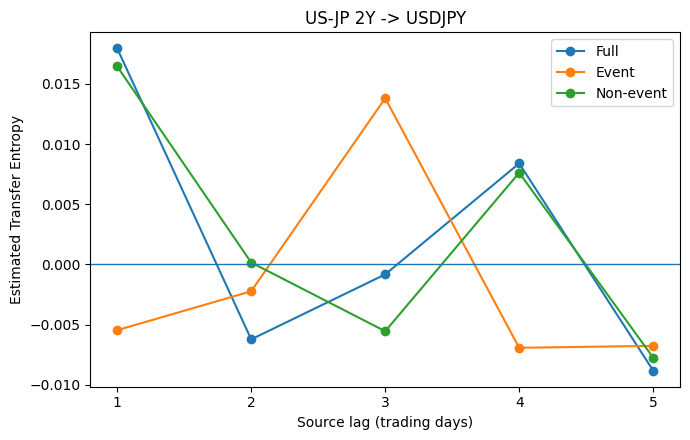

Saved: ../figures/audit_event_te_profile_US-JP_2Y_to_USDJPY.png


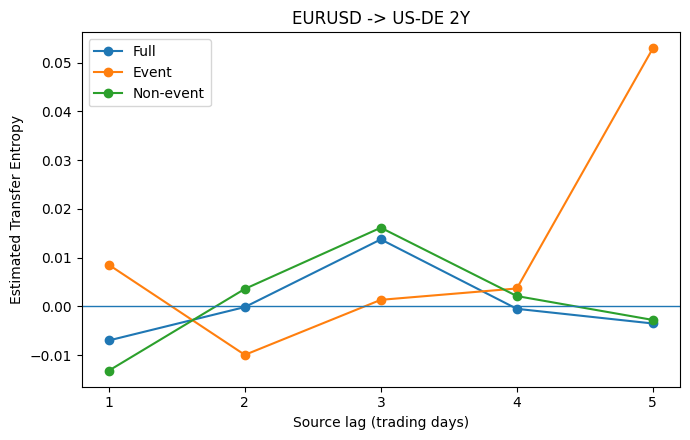

Saved: ../figures/audit_event_te_profile_EURUSD_to_US-DE_2Y.png


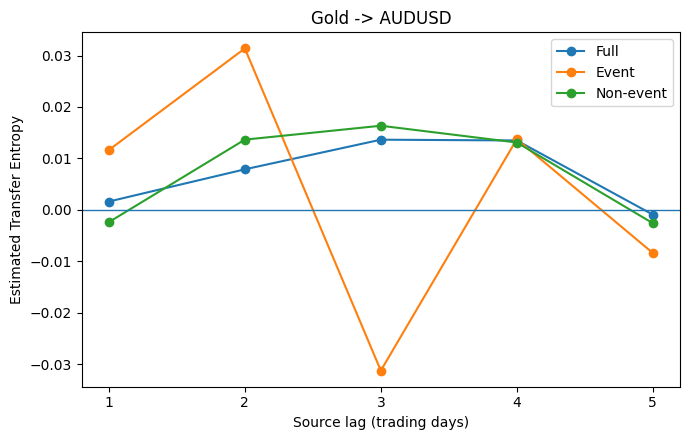

Saved: ../figures/audit_event_te_profile_Gold_to_AUDUSD.png


In [122]:
# ============================================================
# Audit 5: plot TE lag profiles for focus cases
# ============================================================

import matplotlib.pyplot as plt

for label in (
    focus_event_te_summary[
        "Label"
    ].unique()
):

    plot_df = (
        event_te_profile_audit_df[
            event_te_profile_audit_df[
                "Label"
            ] == label
        ]
        .copy()
    )

    fig, ax = plt.subplots(
        figsize=(7, 4.5)
    )

    for state in [
        "Full",
        "Event",
        "Non-event",
    ]:

        state_df = plot_df[
            plot_df["State"] == state
        ]

        ax.plot(
            state_df["Lag"],
            state_df["TE"],
            marker="o",
            label=state,
        )

    ax.axhline(
        0,
        linewidth=1,
    )

    ax.set_xticks(
        TE_LAGS
    )

    ax.set_xlabel(
        "Source lag (trading days)"
    )

    ax.set_ylabel(
        "Estimated Transfer Entropy"
    )

    ax.set_title(
        label
    )

    ax.legend()

    fig.tight_layout()

    safe_name = (
        label
        .replace(" ", "_")
        .replace("->", "to")
        .replace("/", "_")
    )

    audit_png = (
        FIGURE_DIR
        / f"audit_event_te_profile_{safe_name}.png"
    )

    fig.savefig(
        audit_png,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    print(
        f"Saved: {audit_png}"
    )

In [123]:
# ============================================================
# Audit 6: surrogate maximum summaries
# ============================================================

surrogate_audit_rows = []

for channel, direction, label in FOCUS_EVENT_TE_CASES:

    # Full
    full_result = te_details[
        channel
    ][direction]

    full_sur = np.asarray(
        full_result[
            "surrogate_maxima"
        ],
        dtype=float,
    )

    surrogate_audit_rows.append({
        "Label": label,
        "State": "Full",
        "Observed Max TE": full_result[
            "max_TE"
        ],
        "Surrogate mean": full_sur.mean(),
        "Surrogate std": full_sur.std(
            ddof=1
        ),
        "Surrogate 95% quantile": (
            np.quantile(
                full_sur,
                0.95
            )
        ),
        "Global p-value": full_result[
            "global_pvalue"
        ],
    })

    # Event / non-event
    for state in STATES:

        result = event_te_details[
            channel
        ][direction][state]

        sur = np.asarray(
            result[
                "surrogate_maxima"
            ],
            dtype=float,
        )

        surrogate_audit_rows.append({
            "Label": label,
            "State": state,
            "Observed Max TE": result[
                "max_TE"
            ],
            "Surrogate mean": sur.mean(),
            "Surrogate std": sur.std(
                ddof=1
            ),
            "Surrogate 95% quantile": (
                np.quantile(
                    sur,
                    0.95
                )
            ),
            "Global p-value": result[
                "global_pvalue"
            ],
        })

surrogate_audit_df = pd.DataFrame(
    surrogate_audit_rows
)

surrogate_audit_df

,Label,State,Observed Max TE,Surrogate mean,Surrogate std,Surrogate 95% quantile,Global p-value
0,US-JP 2Y -> USDJPY,Full,0.0179,0.0084,0.0047,0.0171,0.0396
1,US-JP 2Y -> USDJPY,Event,0.0138,0.0179,0.0132,0.0393,0.6238
2,US-JP 2Y -> USDJPY,Non-event,0.0165,0.0085,0.0058,0.0185,0.0990
3,EURUSD -> US-DE 2Y,Full,0.0137,0.0079,0.0049,0.0153,0.1287
4,EURUSD -> US-DE 2Y,Event,0.0529,0.0179,0.0106,0.0374,0.0099
5,EURUSD -> US-DE 2Y,Non-event,0.0161,0.0085,0.0046,0.0155,0.0297
6,Gold -> AUDUSD,Full,0.0136,0.0090,0.0046,0.0153,0.1881
7,Gold -> AUDUSD,Event,0.0314,0.0186,0.0105,0.0377,0.1386
8,Gold -> AUDUSD,Non-event,0.0163,0.0082,0.0043,0.0143,0.0495


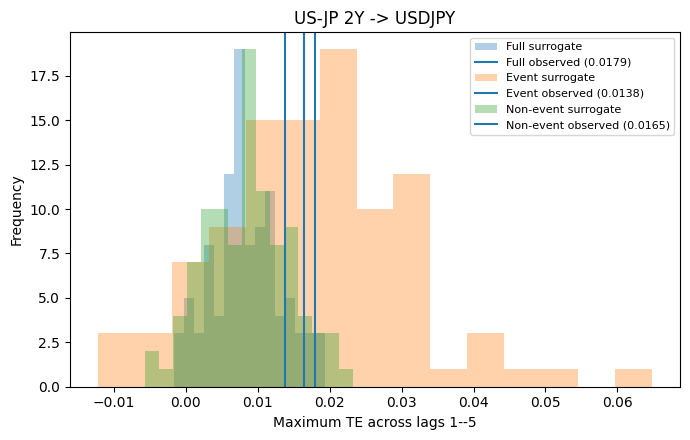

Saved: ../figures/audit_event_te_surrogate_US-JP_2Y_to_USDJPY.png


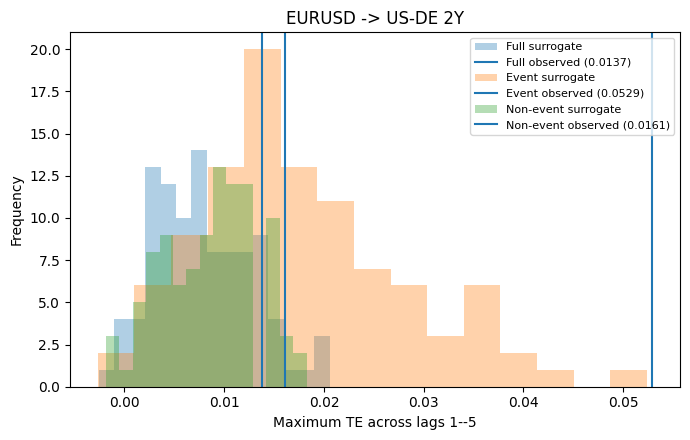

Saved: ../figures/audit_event_te_surrogate_EURUSD_to_US-DE_2Y.png


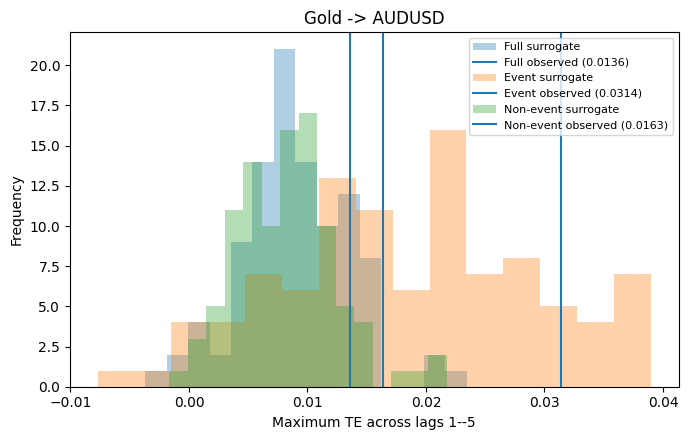

Saved: ../figures/audit_event_te_surrogate_Gold_to_AUDUSD.png


In [124]:
# ============================================================
# Audit 7: surrogate maximum distributions
# ============================================================

for channel, direction, label in FOCUS_EVENT_TE_CASES:

    fig, ax = plt.subplots(
        figsize=(7, 4.5)
    )

    results_by_state = {
        "Full": te_details[
            channel
        ][direction],

        "Event": event_te_details[
            channel
        ][direction]["Event"],

        "Non-event": event_te_details[
            channel
        ][direction]["Non-event"],
    }

    for state, result in (
        results_by_state.items()
    ):

        surrogate_maxima = np.asarray(
            result[
                "surrogate_maxima"
            ],
            dtype=float,
        )

        ax.hist(
            surrogate_maxima,
            bins=15,
            alpha=0.35,
            label=f"{state} surrogate",
        )

        ax.axvline(
            result[
                "max_TE"
                if state == "Full"
                else "max_TE"
            ],
            linewidth=1.5,
            label=(
                f"{state} observed "
                f"({result['max_TE']:.4f})"
            ),
        )

    ax.set_xlabel(
        "Maximum TE across lags 1--5"
    )

    ax.set_ylabel(
        "Frequency"
    )

    ax.set_title(
        label
    )

    ax.legend(
        fontsize=8
    )

    fig.tight_layout()

    safe_name = (
        label
        .replace(" ", "_")
        .replace("->", "to")
        .replace("/", "_")
    )

    audit_png = (
        FIGURE_DIR
        / f"audit_event_te_surrogate_{safe_name}.png"
    )

    fig.savefig(
        audit_png,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    print(
        f"Saved: {audit_png}"
    )

In [125]:
# ============================================================
# Audit 8: diagnostic summary
# ============================================================

diagnostic_rows = []

for channel, direction, label in FOCUS_EVENT_TE_CASES:

    full_result = te_details[
        channel
    ][direction]

    event_result = event_te_details[
        channel
    ][direction]["Event"]

    non_event_result = event_te_details[
        channel
    ][direction]["Non-event"]

    diagnostic_rows.append({
        "Label": label,

        "Full max TE": full_result[
            "max_TE"
        ],
        "Event max TE": event_result[
            "max_TE"
        ],
        "Non-event max TE": non_event_result[
            "max_TE"
        ],

        "Full peak": full_result[
            "peak_lag"
        ],
        "Event peak": event_result[
            "peak_lag"
        ],
        "Non-event peak": non_event_result[
            "peak_lag"
        ],

        "Full p": full_result[
            "global_pvalue"
        ],
        "Event p": event_result[
            "global_pvalue"
        ],
        "Non-event p": non_event_result[
            "global_pvalue"
        ],
    })

event_te_diagnostic_summary = pd.DataFrame(
    diagnostic_rows
)

event_te_diagnostic_summary

,Label,Full max TE,Event max TE,Non-event max TE,Full peak,Event peak,Non-event peak,Full p,Event p,Non-event p
0,US-JP 2Y -> USDJPY,0.0179,0.0138,0.0165,1,3,1,0.0396,0.6238,0.0990
1,EURUSD -> US-DE 2Y,0.0137,0.0529,0.0161,3,5,3,0.1287,0.0099,0.0297
2,Gold -> AUDUSD,0.0136,0.0314,0.0163,3,2,3,0.1881,0.1386,0.0495


### Exploratory test of event-state TE heterogeneity

A supplementary random-window permutation test is used to assess whether the
difference between FOMC-event and non-event TE profiles is unusually large
relative to comparable three-trading-day windows placed elsewhere in the
sample.

For each channel and direction, the observed statistic is

\[
D_{\mathrm{obs}}
=
\max_{\ell=1,\ldots,5}
\left|
TE_{\mathrm{event}}(\ell)
-
TE_{\mathrm{non-event}}(\ell)
\right|.
\]

The null distribution is generated by randomly relocating the same number of
three-trading-day windows on the original trading calendar. Lagged variables
remain constructed on the full chronological series.

This test is treated as an exploratory robustness check rather than part of the
pre-specified baseline inference.

In [126]:
# ============================================================
# TE profile under an arbitrary event-date classification
# ============================================================

def te_profile_for_event_dates(
    x,
    y,
    index,
    event_dates,
    k=TE_K,
    lags=TE_LAGS,
):
    """
    Return Event and Non-event TE profiles for an arbitrary
    set of target dates classified as event dates.
    """

    event_profile = {}
    non_event_profile = {}

    for lag in lags:

        te_event, _ = estimate_event_state_te_lag(
            x=x,
            y=y,
            index=index,
            event_dates=event_dates,
            lag=lag,
            state="Event",
            k=k,
        )

        te_non_event, _ = estimate_event_state_te_lag(
            x=x,
            y=y,
            index=index,
            event_dates=event_dates,
            lag=lag,
            state="Non-event",
            k=k,
        )

        event_profile[lag] = te_event
        non_event_profile[lag] = te_non_event

    return (
        event_profile,
        non_event_profile,
    )

In [127]:
# ============================================================
# Maximum absolute Event vs Non-event TE difference
# ============================================================

def te_state_difference_statistic(
    event_profile,
    non_event_profile,
    lags=TE_LAGS,
):
    """
    D = max_l |TE_event(l) - TE_non_event(l)|
    """

    differences = {
        lag: (
            event_profile[lag]
            - non_event_profile[lag]
        )
        for lag in lags
    }

    abs_differences = {
        lag: abs(value)
        for lag, value
        in differences.items()
    }

    peak_difference_lag = max(
        abs_differences,
        key=abs_differences.get,
    )

    statistic = abs_differences[
        peak_difference_lag
    ]

    return {
        "statistic": float(statistic),
        "peak_difference_lag": int(
            peak_difference_lag
        ),
        "difference_by_lag": differences,
    }

In [128]:
# ============================================================
# Random three-trading-day event windows
# ============================================================

def draw_random_event_windows(
    trading_index,
    n_centres,
    rng,
    max_attempts=10000,
):
    """
    Randomly place n_centres non-overlapping
    {T-1, T, T+1} windows on the trading calendar.

    Returns the union of target dates belonging to the
    random event windows.
    """

    trading_index = pd.DatetimeIndex(
        trading_index
    ).sort_values().unique()

    # Centres cannot be first or last trading observation
    eligible_positions = np.arange(
        1,
        len(trading_index) - 1
    )

    selected_centres = []
    occupied_positions = set()

    attempts = 0

    while (
        len(selected_centres) < n_centres
        and attempts < max_attempts
    ):

        attempts += 1

        centre = int(
            rng.choice(
                eligible_positions
            )
        )

        window_positions = {
            centre - 1,
            centre,
            centre + 1,
        }

        # Prevent overlapping random windows
        if window_positions & occupied_positions:
            continue

        selected_centres.append(
            centre
        )

        occupied_positions.update(
            window_positions
        )

    if len(selected_centres) < n_centres:
        raise RuntimeError(
            "Could not construct enough non-overlapping random windows."
        )

    event_positions = sorted(
        occupied_positions
    )

    return pd.DatetimeIndex(
        trading_index[
            event_positions
        ]
    )

In [129]:
# ============================================================
# One Event vs Non-event TE heterogeneity test
# ============================================================

def run_te_state_heterogeneity_test(
    x,
    y,
    index,
    observed_event_dates,
    n_event_centres,
    k=TE_K,
    lags=TE_LAGS,
    n_permutations=200,
    seed=60000,
):
    """
    Test whether the observed Event vs Non-event TE-profile
    difference is unusually large relative to random
    three-trading-day windows.
    """

    x = np.asarray(
        x,
        dtype=float
    )

    y = np.asarray(
        y,
        dtype=float
    )

    index = pd.DatetimeIndex(
        index
    )

    rng = np.random.default_rng(
        seed
    )

    # --------------------------------------------------------
    # Observed difference
    # --------------------------------------------------------

    (
        observed_event_profile,
        observed_non_event_profile,
    ) = te_profile_for_event_dates(
        x=x,
        y=y,
        index=index,
        event_dates=observed_event_dates,
        k=k,
        lags=lags,
    )

    observed_diff = (
        te_state_difference_statistic(
            observed_event_profile,
            observed_non_event_profile,
            lags=lags,
        )
    )

    observed_stat = observed_diff[
        "statistic"
    ]

    # --------------------------------------------------------
    # Random-window null
    # --------------------------------------------------------

    null_statistics = np.empty(
        n_permutations
    )

    for b in range(
        n_permutations
    ):

        random_event_dates = (
            draw_random_event_windows(
                trading_index=index,
                n_centres=n_event_centres,
                rng=rng,
            )
        )

        (
            random_event_profile,
            random_non_event_profile,
        ) = te_profile_for_event_dates(
            x=x,
            y=y,
            index=index,
            event_dates=random_event_dates,
            k=k,
            lags=lags,
        )

        random_diff = (
            te_state_difference_statistic(
                random_event_profile,
                random_non_event_profile,
                lags=lags,
            )
        )

        null_statistics[b] = (
            random_diff[
                "statistic"
            ]
        )

    # --------------------------------------------------------
    # Monte Carlo p-value
    # --------------------------------------------------------

    pvalue = (
        1
        + np.sum(
            null_statistics >= observed_stat
        )
    ) / (
        n_permutations + 1
    )

    return {
        "observed_statistic": float(
            observed_stat
        ),

        "peak_difference_lag": (
            observed_diff[
                "peak_difference_lag"
            ]
        ),

        "difference_by_lag": (
            observed_diff[
                "difference_by_lag"
            ]
        ),

        "event_profile": (
            observed_event_profile
        ),

        "non_event_profile": (
            observed_non_event_profile
        ),

        "null_statistics": (
            null_statistics
        ),

        "pvalue": float(
            pvalue
        ),

        "significant": bool(
            pvalue < ALPHA
        ),
    }

In [130]:
# ============================================================
# Event-state heterogeneity: focus cases
# ============================================================

te_state_heterogeneity_results = []
te_state_heterogeneity_details = {}

STATE_TEST_PERMUTATIONS = 200

seed_counter = 60000

for (
    channel_name,
    direction,
    label,
) in FOCUS_EVENT_TE_CASES:

    data = (
        channel_data[
            channel_name
        ]["bivariate"]
        .sort_index()
    )

    x_original = (
        data["X"]
        .to_numpy()
    )

    y_original = (
        data["Y"]
        .to_numpy()
    )

    if direction == "X->Y":
        source = x_original
        target = y_original

    else:
        source = y_original
        target = x_original

    event_info = (
        fomc_windows_by_channel[
            channel_name
        ]
    )

    observed_event_dates = (
        event_info[
            "event_dates"
        ]
    )

    # Number of matched FOMC centres, not number of event days
    n_event_centres = len(
        event_info[
            "window_table"
        ]
    )

    print("=" * 70)
    print(label)
    print(
        f"Matched event centres: {n_event_centres}"
    )

    result = (
        run_te_state_heterogeneity_test(
            x=source,
            y=target,
            index=data.index,
            observed_event_dates=observed_event_dates,
            n_event_centres=n_event_centres,
            k=TE_K,
            lags=TE_LAGS,
            n_permutations=STATE_TEST_PERMUTATIONS,
            seed=seed_counter,
        )
    )

    seed_counter += 1

    te_state_heterogeneity_details[
        label
    ] = result

    te_state_heterogeneity_results.append({
        "Relationship": label,
        "Observed max |Event - Non-event TE|": (
            result[
                "observed_statistic"
            ]
        ),
        "Difference peak lag": (
            result[
                "peak_difference_lag"
            ]
        ),
        "Permutation p-value": (
            result[
                "pvalue"
            ]
        ),
        "State heterogeneity significant": (
            result[
                "significant"
            ]
        ),
    })

    print(
        f"p = {result['pvalue']:.4f}"
    )

US-JP 2Y -> USDJPY
Matched event centres: 59
p = 0.7761
EURUSD -> US-DE 2Y
Matched event centres: 74
p = 0.0050
Gold -> AUDUSD
Matched event centres: 80
p = 0.0348


In [131]:
# ============================================================
# Event-state TE heterogeneity summary
# ============================================================

te_state_heterogeneity_df = pd.DataFrame(
    te_state_heterogeneity_results
)

te_state_heterogeneity_df

,Relationship,Observed max |Event - Non-event TE|,Difference peak lag,Permutation p-value,State heterogeneity significant
0,US-JP 2Y -> USDJPY,0.0219,1,0.7761,False
1,EURUSD -> US-DE 2Y,0.0557,5,0.0050,True
2,Gold -> AUDUSD,0.0476,3,0.0348,True


In [132]:
# ============================================================
# Observed Event minus Non-event TE difference by lag
# ============================================================

state_difference_rows = []

for label, result in (
    te_state_heterogeneity_details.items()
):

    for lag, difference in (
        result[
            "difference_by_lag"
        ].items()
    ):

        state_difference_rows.append({
            "Relationship": label,
            "Lag": lag,
            "Event - Non-event TE": difference,
            "Absolute difference": abs(
                difference
            ),
        })

te_state_difference_by_lag_df = (
    pd.DataFrame(
        state_difference_rows
    )
)

te_state_difference_by_lag_df

,Relationship,Lag,Event - Non-event TE,Absolute difference
0,US-JP 2Y -> USDJPY,1,-0.0219,0.0219
1,US-JP 2Y -> USDJPY,2,-0.0024,0.0024
2,US-JP 2Y -> USDJPY,3,0.0194,0.0194
3,US-JP 2Y -> USDJPY,4,-0.0146,0.0146
4,US-JP 2Y -> USDJPY,5,0.0010,0.0010
5,EURUSD -> US-DE 2Y,1,0.0217,0.0217
6,EURUSD -> US-DE 2Y,2,-0.0135,0.0135
7,EURUSD -> US-DE 2Y,3,-0.0148,0.0148
8,EURUSD -> US-DE 2Y,4,0.0016,0.0016
9,EURUSD -> US-DE 2Y,5,0.0557,0.0557


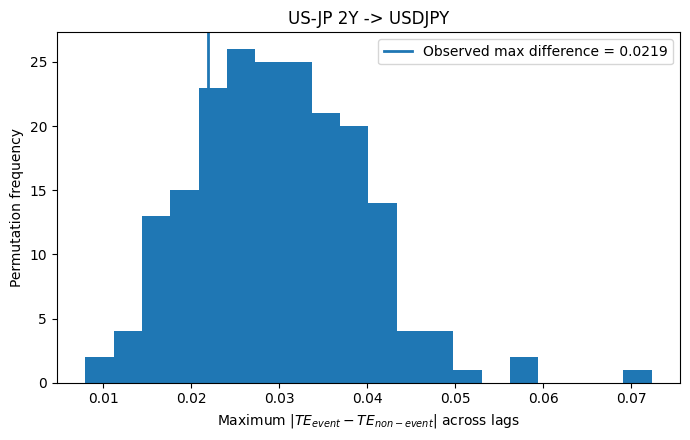

Saved: ../figures/te_state_heterogeneity_US-JP_2Y_to_USDJPY.png


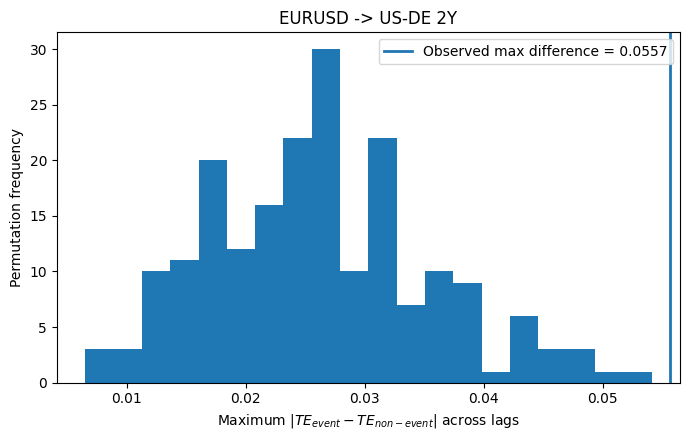

Saved: ../figures/te_state_heterogeneity_EURUSD_to_US-DE_2Y.png


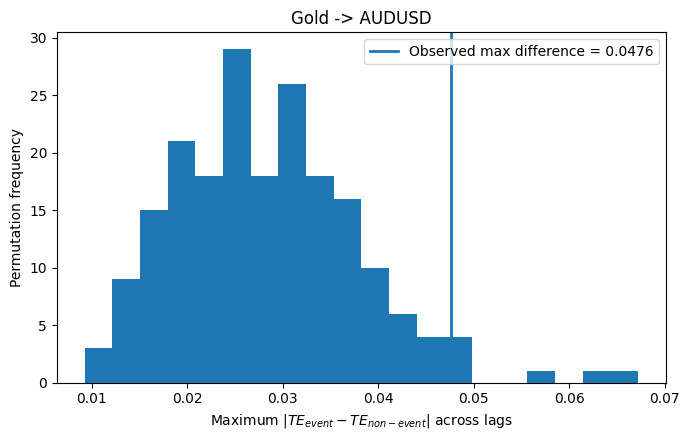

Saved: ../figures/te_state_heterogeneity_Gold_to_AUDUSD.png


In [133]:
# ============================================================
# Plot Event vs Non-event heterogeneity null
# ============================================================

import matplotlib.pyplot as plt

for label, result in (
    te_state_heterogeneity_details.items()
):

    fig, ax = plt.subplots(
        figsize=(7, 4.5)
    )

    ax.hist(
        result[
            "null_statistics"
        ],
        bins=20,
    )

    ax.axvline(
        result[
            "observed_statistic"
        ],
        linewidth=2,
        label=(
            "Observed max difference "
            f"= {result['observed_statistic']:.4f}"
        ),
    )

    ax.set_xlabel(
        r"Maximum $|TE_{event}-TE_{non-event}|$ across lags"
    )

    ax.set_ylabel(
        "Permutation frequency"
    )

    ax.set_title(
        label
    )

    ax.legend()

    fig.tight_layout()

    safe_name = (
        label
        .replace(" ", "_")
        .replace("->", "to")
    )

    figure_file = (
        FIGURE_DIR
        / f"te_state_heterogeneity_{safe_name}.png"
    )

    fig.savefig(
        figure_file,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    print(
        f"Saved: {figure_file}"
    )

### Robustness of FOMC-state TE heterogeneity

Two targeted robustness checks are performed.

First, the EURUSD-to-US--Germany 2Y heterogeneity test is repeated with 1,000
random-window permutations to obtain a more precise Monte Carlo p-value.

Second, the USDCAD-to-Brent direction is tested because linear GC detected an
event-only relationship in this direction. The same TE state-heterogeneity
statistic and random-window procedure are used without changing the baseline
TE specification.

In [134]:
# ============================================================
# Robustness 1: EURUSD -> US-DE 2Y with 1,000 permutations
# ============================================================

EURUSD_USDE_CHANNEL = "US-DE 2Y -> EURUSD"
EURUSD_USDE_DIRECTION = "Y->X"

data = (
    channel_data[
        EURUSD_USDE_CHANNEL
    ]["bivariate"]
    .sort_index()
)

x_original = data["X"].to_numpy()
y_original = data["Y"].to_numpy()

# Y->X:
# original FX becomes source,
# original rate differential becomes target
source = y_original
target = x_original

event_info = (
    fomc_windows_by_channel[
        EURUSD_USDE_CHANNEL
    ]
)

eurusd_usde_1000 = (
    run_te_state_heterogeneity_test(
        x=source,
        y=target,
        index=data.index,
        observed_event_dates=event_info["event_dates"],
        n_event_centres=len(
            event_info["window_table"]
        ),
        k=TE_K,
        lags=TE_LAGS,
        n_permutations=1000,
        seed=71000,
    )
)

print("EURUSD -> US-DE 2Y")
print(
    "Observed max difference:",
    round(
        eurusd_usde_1000[
            "observed_statistic"
        ],
        4,
    )
)

print(
    "Peak difference lag:",
    eurusd_usde_1000[
        "peak_difference_lag"
    ]
)

print(
    "Permutation p-value:",
    round(
        eurusd_usde_1000[
            "pvalue"
        ],
        4,
    )
)

print(
    "Significant:",
    eurusd_usde_1000[
        "significant"
    ]
)

EURUSD -> US-DE 2Y
Observed max difference: 0.0557
Peak difference lag: 5
Permutation p-value: 0.002
Significant: True


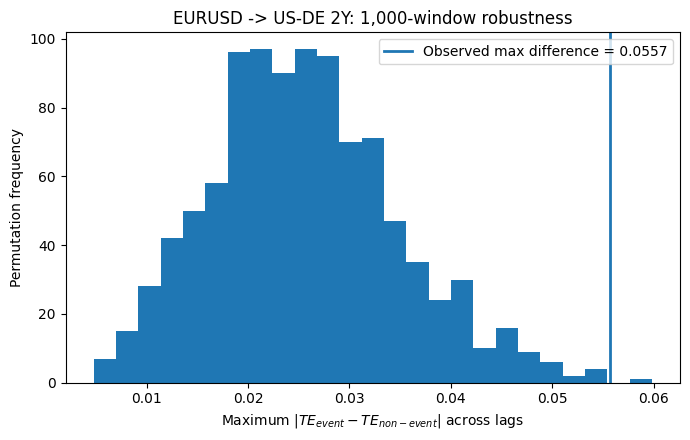

Saved: ../figures/te_state_heterogeneity_EURUSD_to_US-DE_2Y_1000.png


In [135]:
# ============================================================
# EURUSD -> US-DE 2Y robustness figure
# ============================================================

fig, ax = plt.subplots(
    figsize=(7, 4.5)
)

ax.hist(
    eurusd_usde_1000[
        "null_statistics"
    ],
    bins=25,
)

ax.axvline(
    eurusd_usde_1000[
        "observed_statistic"
    ],
    linewidth=2,
    label=(
        "Observed max difference "
        f"= {eurusd_usde_1000['observed_statistic']:.4f}"
    ),
)

ax.set_xlabel(
    r"Maximum $|TE_{event}-TE_{non-event}|$ across lags"
)

ax.set_ylabel(
    "Permutation frequency"
)

ax.set_title(
    "EURUSD -> US-DE 2Y: 1,000-window robustness"
)

ax.legend()

fig.tight_layout()

EURUSD_STATE_ROBUSTNESS_FIG = (
    FIGURE_DIR
    / "te_state_heterogeneity_EURUSD_to_US-DE_2Y_1000.png"
)

fig.savefig(
    EURUSD_STATE_ROBUSTNESS_FIG,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    f"Saved: {EURUSD_STATE_ROBUSTNESS_FIG}"
)

In [136]:
# ============================================================
# Robustness 2: USDCAD -> Brent TE state heterogeneity
# ============================================================

USDCAD_BRENT_CHANNEL = "Brent -> USDCAD"
USDCAD_BRENT_DIRECTION = "Y->X"

data = (
    channel_data[
        USDCAD_BRENT_CHANNEL
    ]["bivariate"]
    .sort_index()
)

x_original = data["X"].to_numpy()
y_original = data["Y"].to_numpy()

# Y->X:
# USDCAD becomes source,
# Brent becomes target
source = y_original
target = x_original

event_info = (
    fomc_windows_by_channel[
        USDCAD_BRENT_CHANNEL
    ]
)

usdcad_brent_heterogeneity = (
    run_te_state_heterogeneity_test(
        x=source,
        y=target,
        index=data.index,
        observed_event_dates=event_info["event_dates"],
        n_event_centres=len(
            event_info["window_table"]
        ),
        k=TE_K,
        lags=TE_LAGS,
        n_permutations=1000,
        seed=72000,
    )
)

print("USDCAD -> Brent")
print(
    "Observed max difference:",
    round(
        usdcad_brent_heterogeneity[
            "observed_statistic"
        ],
        4,
    )
)

print(
    "Peak difference lag:",
    usdcad_brent_heterogeneity[
        "peak_difference_lag"
    ]
)

print(
    "Permutation p-value:",
    round(
        usdcad_brent_heterogeneity[
            "pvalue"
        ],
        4,
    )
)

print(
    "Significant:",
    usdcad_brent_heterogeneity[
        "significant"
    ]
)

USDCAD -> Brent
Observed max difference: 0.0191
Peak difference lag: 5
Permutation p-value: 0.6144
Significant: False


In [137]:
# ============================================================
# USDCAD -> Brent Event minus Non-event TE by lag
# ============================================================

usdcad_brent_difference_df = pd.DataFrame(
    [
        {
            "Lag": lag,
            "Event - Non-event TE": difference,
            "Absolute difference": abs(
                difference
            ),
        }
        for lag, difference in (
            usdcad_brent_heterogeneity[
                "difference_by_lag"
            ].items()
        )
    ]
)

usdcad_brent_difference_df

,Lag,Event - Non-event TE,Absolute difference
0,1,0.0118,0.0118
1,2,0.0051,0.0051
2,3,-0.0173,0.0173
3,4,0.0048,0.0048
4,5,-0.0191,0.0191


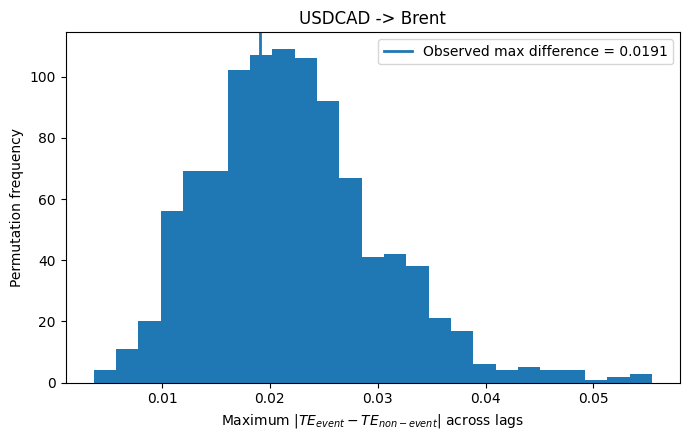

Saved: ../figures/te_state_heterogeneity_USDCAD_to_Brent.png


In [138]:
# ============================================================
# USDCAD -> Brent heterogeneity null
# ============================================================

fig, ax = plt.subplots(
    figsize=(7, 4.5)
)

ax.hist(
    usdcad_brent_heterogeneity[
        "null_statistics"
    ],
    bins=25,
)

ax.axvline(
    usdcad_brent_heterogeneity[
        "observed_statistic"
    ],
    linewidth=2,
    label=(
        "Observed max difference "
        f"= {usdcad_brent_heterogeneity['observed_statistic']:.4f}"
    ),
)

ax.set_xlabel(
    r"Maximum $|TE_{event}-TE_{non-event}|$ across lags"
)

ax.set_ylabel(
    "Permutation frequency"
)

ax.set_title(
    "USDCAD -> Brent"
)

ax.legend()

fig.tight_layout()

USDCAD_BRENT_STATE_FIG = (
    FIGURE_DIR
    / "te_state_heterogeneity_USDCAD_to_Brent.png"
)

fig.savefig(
    USDCAD_BRENT_STATE_FIG,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    f"Saved: {USDCAD_BRENT_STATE_FIG}"
)

In [139]:
# ============================================================
# Targeted FOMC-state TE robustness summary
# ============================================================

targeted_state_robustness_df = pd.DataFrame(
    [
        {
            "Relationship": "EURUSD -> US-DE 2Y",
            "Permutations": 1000,
            "Observed max difference": (
                eurusd_usde_1000[
                    "observed_statistic"
                ]
            ),
            "Difference peak lag": (
                eurusd_usde_1000[
                    "peak_difference_lag"
                ]
            ),
            "Permutation p-value": (
                eurusd_usde_1000[
                    "pvalue"
                ]
            ),
            "Significant": (
                eurusd_usde_1000[
                    "significant"
                ]
            ),
        },
        {
            "Relationship": "USDCAD -> Brent",
            "Permutations": 1000,
            "Observed max difference": (
                usdcad_brent_heterogeneity[
                    "observed_statistic"
                ]
            ),
            "Difference peak lag": (
                usdcad_brent_heterogeneity[
                    "peak_difference_lag"
                ]
            ),
            "Permutation p-value": (
                usdcad_brent_heterogeneity[
                    "pvalue"
                ]
            ),
            "Significant": (
                usdcad_brent_heterogeneity[
                    "significant"
                ]
            ),
        },
    ]
)

targeted_state_robustness_df

,Relationship,Permutations,Observed max difference,Difference peak lag,Permutation p-value,Significant
0,EURUSD -> US-DE 2Y,1000,0.0557,5,0.0020,True
1,USDCAD -> Brent,1000,0.0191,5,0.6144,False


In [140]:
TARGETED_STATE_ROBUSTNESS_FILE = (
    TABLE_DIR
    / "fomc_te_state_heterogeneity_robustness.csv"
)

targeted_state_robustness_df.to_csv(
    TARGETED_STATE_ROBUSTNESS_FILE,
    index=False,
)

print(
    f"Saved: {TARGETED_STATE_ROBUSTNESS_FILE}"
)

Saved: ../tables/fomc_te_state_heterogeneity_robustness.csv
